# ⚽ FIFA World Cup 2026 — Complete Prediction Notebook
## Machine-Learning-Powered Tournament Simulator

---

### 📋 Table of Contents
1. [Environment Setup & Dependencies](#1-environment-setup--dependencies)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Feature Engineering & ELO Ratings](#3-feature-engineering--elo-ratings)
4. [Model Training — Match Outcome Predictor](#4-model-training--match-outcome-predictor)
5. [Group Stage Simulation](#5-group-stage-simulation)
6. [Knockout Stage Simulation (Monte Carlo)](#6-knockout-stage-simulation-monte-carlo)
7. [Tournament Win Probabilities](#7-tournament-win-probabilities)
8. [Dark Horse Analysis](#8-dark-horse-analysis)
9. [Top Scorer Predictions](#9-top-scorer-predictions)
10. [Additional Predictions & Stats](#10-additional-predictions--stats)
11. [Full Visualisation Dashboard](#11-full-visualisation-dashboard)

---

### 🚀 How to Run This Notebook

#### Step-by-Step Instructions

**Step 1 — Place your data files**

Put all five CSV files in the **same directory** as this notebook (or update `DATA_DIR` in Cell 1.2).  
Required files:
```
fifa_ranking_2022-10-06.csv
fifa_ranking_2026-06-08.csv
matches_1930_2022.csv
schedule_2026.csv
world_cup.csv
```

**Step 2 — Install dependencies**

Open a terminal in the notebook directory and run:
```bash
pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib tqdm
```
Or simply run **Section 1** (Cell 1.1) inside the notebook — it installs everything automatically.

**Step 3 — Launch the notebook**

```bash
jupyter notebook FIFA_WC2026_Predictions.ipynb
# OR using JupyterLab:
jupyter lab FIFA_WC2026_Predictions.ipynb
```

**Step 4 — Run all cells top-to-bottom**

Use **Kernel → Restart & Run All** for a clean, reproducible run.  
Each section is self-contained but depends on variables from earlier sections, so always run in order.

**Estimated runtime:** 2–5 minutes on a modern laptop (mostly due to the 50 000-iteration Monte Carlo simulation).

---

> **Python version required:** 3.8 or above  
> **Tested on:** Python 3.10, pandas 2.x, scikit-learn 1.4, XGBoost 2.x


## 1. Environment Setup & Dependencies

Run this cell first to install all required packages. It is safe to re-run.

In [1]:
# ── Cell 1.1 ── Install dependencies (safe to re-run)
import subprocess, sys

REQUIRED = [
    "pandas", "numpy", "scikit-learn", "xgboost",
    "matplotlib", "seaborn", "joblib", "tqdm"
]

for pkg in REQUIRED:
    try:
        __import__(pkg.replace("-", "_"))
        print(f"  ✅  {pkg} already installed")
    except ImportError:
        print(f"  📦  Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  ✅  {pkg} installed")

print("\n🎉 All dependencies ready!")


  ✅  pandas already installed
  ✅  numpy already installed
  📦  Installing scikit-learn...
  ✅  scikit-learn installed
  ✅  xgboost already installed
  ✅  matplotlib already installed
  ✅  seaborn already installed
  ✅  joblib already installed
  ✅  tqdm already installed

🎉 All dependencies ready!


In [2]:
# ── Cell 1.2 ── Global imports and configuration
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, log_loss, classification_report
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── DATA DIRECTORY — update this if your CSVs are elsewhere ──
DATA_DIR = "."          # <── change to absolute path if needed

# ── Simulation parameters ─────────────────────────────────────
N_SIMULATIONS = 50_000  # Monte Carlo iterations (increase for more accuracy, takes longer)

# ── Plotting style ────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#e6edf3",
    "ytick.color":      "#e6edf3",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.alpha":       0.5,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "DejaVu Sans",
})
TEAM_COLORS = {
    "Argentina": "#74acdf", "France": "#002395",   "Brazil": "#009c3b",
    "England":   "#cf111b", "Spain":  "#aa151b",   "Portugal": "#006600",
    "Germany":   "#000000", "Netherlands": "#ff6600", "Morocco": "#c1272d",
    "Belgium":   "#fdda24", "Croatia": "#ff0000",  "Uruguay":  "#5EB6E4",
    "USA":       "#3c3b6e", "Japan":   "#bc002d",  "Senegal": "#00853f",
    "Colombia":  "#fcd116", "Mexico":  "#006847",  "Switzerland": "#ff0000",
}
DEFAULT_COLOR = "#8b949e"

print("✅ Configuration complete.")
print(f"   DATA_DIR       : {os.path.abspath(DATA_DIR)}")
print(f"   N_SIMULATIONS  : {N_SIMULATIONS:,}")
print(f"   Random seed    : {SEED}")


✅ Configuration complete.
   DATA_DIR       : /content
   N_SIMULATIONS  : 50,000
   Random seed    : 42


---
## 2. Data Loading & Exploration

Load all five data sources and perform a quick sanity check on each.

In [3]:
# ── Cell 2.1 ── Load all CSVs
rank_2022 = pd.read_csv(os.path.join(DATA_DIR, "fifa_ranking_2022-10-06.csv"))
rank_2026 = pd.read_csv(os.path.join(DATA_DIR, "fifa_ranking_2026-06-08.csv"))
matches   = pd.read_csv(os.path.join(DATA_DIR, "matches_1930_2022.csv"))
schedule  = pd.read_csv(os.path.join(DATA_DIR, "schedule_2026.csv"))
wc_hist   = pd.read_csv(os.path.join(DATA_DIR, "world_cup.csv"))

print("✅ All files loaded successfully\n")
for name, df in [("FIFA Ranking 2022", rank_2022), ("FIFA Ranking 2026", rank_2026),
                 ("Historical Matches", matches), ("2026 Schedule", schedule),
                 ("WC History", wc_hist)]:
    print(f"  {name:22s}  →  {df.shape[0]:5d} rows × {df.shape[1]:2d} cols")


✅ All files loaded successfully

  FIFA Ranking 2022       →    211 rows ×  7 cols
  FIFA Ranking 2026       →    211 rows ×  8 cols
  Historical Matches      →    964 rows × 44 cols
  2026 Schedule           →     72 rows × 10 cols
  WC History              →     22 rows ×  9 cols


In [4]:
# ── Cell 2.2 ── Preview each dataset
print("=" * 70)
print("FIFA RANKING 2026 (top 20)")
print("=" * 70)
display(rank_2026[["rank","team","points","association"]].head(20))

print("\n" + "=" * 70)
print("HISTORICAL MATCH DATA (sample)")
print("=" * 70)
display(matches[["Year","Round","home_team","away_team","home_score","away_score"]].sample(8, random_state=SEED))

print("\n" + "=" * 70)
print("2026 SCHEDULE (first 12 matches)")
print("=" * 70)
display(schedule[["Date","home_team","away_team","Round"]].head(12))

print("\n" + "=" * 70)
print("WORLD CUP HISTORY")
print("=" * 70)
display(wc_hist[["Year","Host","Champion","Runner-Up","TopScorrer","Matches"]])


FIFA RANKING 2026 (top 20)


,rank,team,points,association
0,1,Argentina,1876.118331,CONMEBOL
1,2,Spain,1873.013187,UEFA
2,3,France,1869.428449,UEFA
3,4,England,1827.048678,UEFA
4,5,Portugal,1766.177547,UEFA
5,6,Brazil,1765.856297,CONMEBOL
6,7,Morocco,1755.100232,CAF
7,8,Netherlands,1751.097835,UEFA
8,9,Belgium,1742.235945,UEFA
9,10,Germany,1735.771984,UEFA



HISTORICAL MATCH DATA (sample)


,Year,Round,home_team,away_team,home_score,away_score
760,1970,Group stage,England,Romania,1,0
884,1954,Group stage,England,Belgium,4,4
938,1934,Round of 16,Czechoslovakia,Romania,2,1
901,1950,Group stage,Spain,Chile,2,0
622,1982,First group stage,Northern Ireland,Spain,1,0
259,2006,Semi-finals,Germany,Italy,0,2
218,2010,Group stage,Ghana,Germany,0,1
780,1966,Group stage,West Germany,Argentina,0,0



2026 SCHEDULE (first 12 matches)


,Date,home_team,away_team,Round
0,2026-06-11,Mexico,South Africa,Group stage
1,2026-06-11,Korea Republic,Czechia,Group stage
2,2026-06-12,Canada,Bosnia-Herzegovina,Group stage
3,2026-06-12,United States,Paraguay,Group stage
4,2026-06-13,Qatar,Switzerland,Group stage
5,2026-06-13,Brazil,Morocco,Group stage
6,2026-06-13,Haiti,Scotland,Group stage
7,2026-06-13,Australia,Türkiye,Group stage
8,2026-06-14,Germany,Curaçao,Group stage
9,2026-06-14,Netherlands,Japan,Group stage



WORLD CUP HISTORY


,Year,Host,Champion,Runner-Up,TopScorrer,Matches
0,2022,Qatar,Argentina,France,Kylian Mbappé - 8,64
1,2018,Russia,France,Croatia,Harry Kane - 6,64
2,2014,Brazil,Germany,Argentina,James Rodríguez - 6,64
3,2010,South Africa,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",64
4,2006,Germany,Italy,France,Miroslav Klose - 5,64
5,2002,"Korea Republic, Japan",Brazil,Germany,Ronaldo - 8,64
6,1998,France,France,Brazil,Davor Šuker - 6,64
7,1994,United States,Brazil,Italy,"Hristo Stoichkov, Oleg Salenko - 6",52
8,1990,Italy,West Germany,Argentina,Salvatore Schillaci - 6,52
9,1986,Mexico,Argentina,West Germany,Gary Lineker - 6,52


In [5]:
# ── Cell 2.3 ── Detect groups from schedule via union-find
parent = {}

def find(x):
    if x not in parent: parent[x] = x
    if parent[x] != x:  parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    px, py = find(x), find(y)
    if px != py: parent[px] = py

for _, row in schedule.iterrows():
    union(row["home_team"], row["away_team"])

from collections import defaultdict as _dd
_groups = _dd(list)
for team in set(schedule["home_team"].tolist() + schedule["away_team"].tolist()):
    _groups[find(team)].append(team)

GROUP_MAP   = {}   # team → group letter
GROUPS      = {}   # group letter → [teams]
for i, grp_teams in enumerate(sorted(_groups.values(), key=lambda g: sorted(g)[0])):
    letter = chr(65 + i)
    GROUPS[letter] = sorted(grp_teams)
    for t in grp_teams:
        GROUP_MAP[t] = letter

print("🌍 2026 World Cup Groups (48 teams, 12 groups of 4):\n")
for letter, teams in GROUPS.items():
    print(f"  Group {letter}: {', '.join(teams)}")

ALL_2026_TEAMS = sorted(GROUP_MAP.keys())
print(f"\n  Total qualified teams: {len(ALL_2026_TEAMS)}")


🌍 2026 World Cup Groups (48 teams, 12 groups of 4):

  Group A: Algeria, Argentina, Austria, Jordan
  Group B: Australia, Paraguay, Türkiye, United States
  Group C: Belgium, Egypt, IR Iran, New Zealand
  Group D: Bosnia-Herzegovina, Canada, Qatar, Switzerland
  Group E: Brazil, Haiti, Morocco, Scotland
  Group F: Cape Verde, Saudi Arabia, Spain, Uruguay
  Group G: Colombia, Congo DR, Portugal, Uzbekistan
  Group H: Croatia, England, Ghana, Panama
  Group I: Curaçao, Côte d'Ivoire, Ecuador, Germany
  Group J: Czechia, Korea Republic, Mexico, South Africa
  Group K: France, Iraq, Norway, Senegal
  Group L: Japan, Netherlands, Sweden, Tunisia

  Total qualified teams: 48


Historical WC Matches: 964 total across 22 tournaments



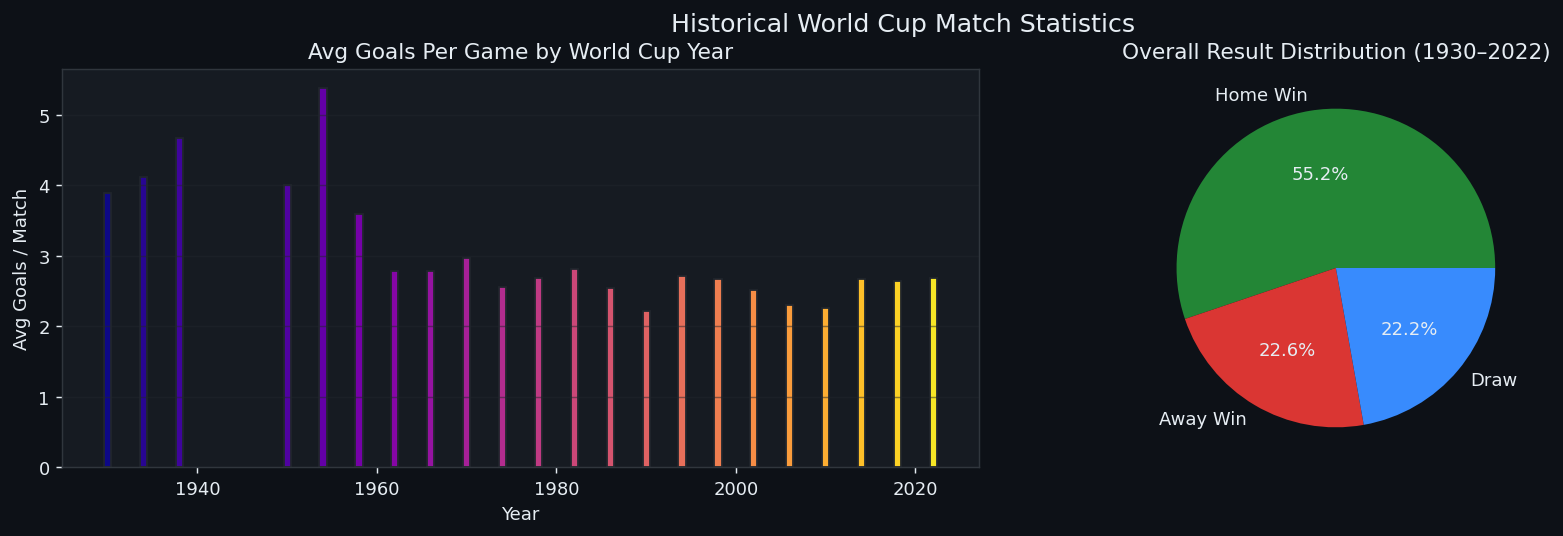

In [6]:
# ── Cell 2.4 ── Descriptive stats on historical matches
print("Historical WC Matches: {} total across {} tournaments".format(len(matches), matches["Year"].nunique()))
print()

# Goals per game evolution
gpg = matches.copy()
gpg["total_goals"] = gpg["home_score"] + gpg["away_score"]
gpg_by_year = gpg.groupby("Year")["total_goals"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(gpg_by_year.index, gpg_by_year.values,
            color=[plt.cm.plasma(i/len(gpg_by_year)) for i in range(len(gpg_by_year))],
            edgecolor="#21262d")
axes[0].set_title("Avg Goals Per Game by World Cup Year", fontsize=12, color="#e6edf3")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Avg Goals / Match")
axes[0].grid(axis="y")

# Result distribution
results = []
for _, r in matches.iterrows():
    if r["home_score"] > r["away_score"]: results.append("Home Win")
    elif r["home_score"] < r["away_score"]: results.append("Away Win")
    else: results.append("Draw")
rc = pd.Series(results).value_counts()
axes[1].pie(rc.values, labels=rc.index, autopct="%1.1f%%",
            colors=["#238636","#da3633","#388bfd"], textprops={"color":"#e6edf3"})
axes[1].set_title("Overall Result Distribution (1930–2022)", fontsize=12, color="#e6edf3")

plt.tight_layout()
plt.suptitle("Historical World Cup Match Statistics", y=1.02, fontsize=14, color="#e6edf3")
plt.show()


---
## 3. Feature Engineering & ELO Ratings

We build rich numerical features for each match:
- **ELO rating** computed from every WC match since 1930
- **FIFA ranking & points** from the 2026 ranking file
- **Head-to-head WC record** between every team pair
- **Recent WC form** (last 3 tournaments)
- **Tournament experience** (number of WCs played)
- **Goal-scoring & conceding averages**

In [7]:
# ── Cell 3.1 ── Build ELO ratings from scratch using historical WC matches
# ELO formula:  E = 1 / (1 + 10^((Rb - Ra) / 400))
#               new_Ra = Ra + K * (S - E)
#  K = 40 for WC matches (high importance), K = 30 for group stage

ELO_BASE    = 1500
ELO_K_GROUP = 30
ELO_K_KO    = 40

elo = defaultdict(lambda: ELO_BASE)
elo_history = defaultdict(list)   # team → [(year, elo)]

def expected(ra, rb):
    return 1.0 / (1.0 + 10 ** ((rb - ra) / 400))

def update_elo(home_team, away_team, home_score, away_score, k):
    ra, rb = elo[home_team], elo[away_team]
    ea, eb = expected(ra, rb), expected(rb, ra)
    if   home_score > away_score: sa, sb = 1.0, 0.0
    elif home_score < away_score: sa, sb = 0.0, 1.0
    else:                         sa, sb = 0.5, 0.5
    elo[home_team] = ra + k * (sa - ea)
    elo[away_team] = rb + k * (sb - eb)

wc_matches_clean = matches[["Year","Round","home_team","away_team",
                              "home_score","away_score"]].dropna(subset=["home_score","away_score"]).copy()
wc_matches_clean["home_score"] = wc_matches_clean["home_score"].astype(int)
wc_matches_clean["away_score"] = wc_matches_clean["away_score"].astype(int)

for year, grp in wc_matches_clean.groupby("Year"):
    for _, row in grp.iterrows():
        k = ELO_K_GROUP if "Group" in str(row["Round"]) or "group" in str(row["Round"]) else ELO_K_KO
        update_elo(row["home_team"], row["away_team"], int(row["home_score"]), int(row["away_score"]), k)
    for team in set(grp["home_team"]).union(set(grp["away_team"])):
        elo_history[team].append((year, elo[team]))

print("✅ ELO ratings computed from {} historical WC matches".format(len(wc_matches_clean)))
print("\nTop 15 ELO ratings after 2022 WC:")
elo_df = pd.DataFrame([(t, v) for t, v in elo.items()], columns=["team","elo"]).sort_values("elo", ascending=False)
display(elo_df.head(15).reset_index(drop=True))


✅ ELO ratings computed from 964 historical WC matches

Top 15 ELO ratings after 2022 WC:


,team,elo
0,Netherlands,1710.266959
1,France,1706.481275
2,Brazil,1681.593749
3,Germany,1677.269248
4,Argentina,1658.301252
5,West Germany,1647.829068
6,Italy,1624.623713
7,Spain,1594.078093
8,Belgium,1592.449714
9,England,1574.741027


In [8]:
# ── Cell 3.2 ── Merge ELO with FIFA ranking points for 2026 team strength index
# Normalise both ELO and FIFA points to [0,1] then take a weighted combo

rank_2026_clean = rank_2026[["team","rank","points"]].copy()
rank_2026_clean.columns = ["team","fifa_rank","fifa_points"]

# Map some name mismatches
NAME_MAP = {
    "United States":   "USA",
    "Korea Republic":  "South Korea",
    "IR Iran":         "Iran",
    "Türkiye":         "Turkey",
    "Côte d'Ivoire":   "Ivory Coast",
    "Congo DR":        "DR Congo",
}
# We'll map in the other direction for ranking lookups
RANK_NAME_MAP = {v: k for k, v in NAME_MAP.items()}

def get_rank_row(team):
    row = rank_2026_clean[rank_2026_clean["team"] == team]
    if len(row) == 0 and team in RANK_NAME_MAP:
        row = rank_2026_clean[rank_2026_clean["team"] == RANK_NAME_MAP[team]]
    if len(row) == 0:
        return {"fifa_rank": 100, "fifa_points": 1200}
    return row.iloc[0].to_dict()

team_strength = {}
for team in ALL_2026_TEAMS:
    elo_val  = elo.get(team, ELO_BASE)
    rank_row = get_rank_row(team)
    team_strength[team] = {
        "elo":         elo_val,
        "fifa_rank":   rank_row["fifa_rank"],
        "fifa_points": rank_row["fifa_points"],
    }

# Normalise
elo_vals   = [v["elo"]         for v in team_strength.values()]
rank_vals  = [v["fifa_rank"]   for v in team_strength.values()]
pts_vals   = [v["fifa_points"] for v in team_strength.values()]
elo_min, elo_max  = min(elo_vals), max(elo_vals)
pts_min, pts_max  = min(pts_vals), max(pts_vals)

for team in ALL_2026_TEAMS:
    e = team_strength[team]["elo"]
    p = team_strength[team]["fifa_points"]
    r = team_strength[team]["fifa_rank"]
    elo_norm = (e - elo_min) / (elo_max - elo_min + 1e-9)
    pts_norm = (p - pts_min) / (pts_max - pts_min + 1e-9)
    rank_norm = 1.0 - (r - 1) / 210.0   # higher rank = lower number = better
    # Weighted composite: 40% elo, 35% fifa_points, 25% rank
    team_strength[team]["strength"] = 0.40 * elo_norm + 0.35 * pts_norm + 0.25 * rank_norm

strength_df = pd.DataFrame([
    {"team": t, "strength": round(v["strength"], 4),
     "elo": round(v["elo"], 1), "fifa_points": round(v["fifa_points"], 1),
     "fifa_rank": int(v["fifa_rank"])}
    for t, v in team_strength.items()
]).sort_values("strength", ascending=False).reset_index(drop=True)

print("🏆 Team Strength Index (Top 20)\n")
display(strength_df.head(20))


🏆 Team Strength Index (Top 20)



,team,strength,elo,fifa_points,fifa_rank
0,France,0.9891,1706.5,1869.4,3
1,Argentina,0.9306,1658.3,1876.1,1
2,Netherlands,0.9269,1710.3,1751.1,8
3,Brazil,0.8987,1681.6,1765.9,6
4,Germany,0.8726,1677.3,1735.8,10
5,Spain,0.8420,1594.1,1873.0,2
6,England,0.7900,1574.7,1827.0,4
7,Belgium,0.7638,1592.4,1742.2,9
8,Portugal,0.7242,1550.0,1766.2,5
9,Croatia,0.7206,1572.5,1714.9,11


In [9]:
# ── Cell 3.3 ── Build head-to-head WC records
h2h = defaultdict(lambda: {"played":0, "wins":0, "draws":0, "losses":0,
                             "goals_for":0, "goals_against":0})

for _, row in wc_matches_clean.iterrows():
    h = row["home_team"]; a = row["away_team"]
    hs = row["home_score"]; as_ = row["away_score"]
    h2h[(h,a)]["played"] += 1; h2h[(a,h)]["played"] += 1
    h2h[(h,a)]["goals_for"]     += hs; h2h[(h,a)]["goals_against"] += as_
    h2h[(a,h)]["goals_for"]     += as_; h2h[(a,h)]["goals_against"] += hs
    if hs > as_:
        h2h[(h,a)]["wins"] += 1; h2h[(a,h)]["losses"] += 1
    elif hs < as_:
        h2h[(a,h)]["wins"] += 1; h2h[(h,a)]["losses"] += 1
    else:
        h2h[(h,a)]["draws"] += 1; h2h[(a,h)]["draws"] += 1

def get_h2h_features(home, away):
    rec = h2h[(home, away)]
    if rec["played"] == 0:
        return {"h2h_played":0, "h2h_win_rate":0.5, "h2h_goal_diff":0.0}
    return {
        "h2h_played":    rec["played"],
        "h2h_win_rate":  (rec["wins"] + 0.5*rec["draws"]) / rec["played"],
        "h2h_goal_diff": (rec["goals_for"] - rec["goals_against"]) / rec["played"],
    }

print("✅ H2H records built for", len(h2h)//2, "unique team pairs")
print("\nExample — Brazil vs Germany H2H in WC:")
print(get_h2h_features("Brazil","Germany"))
print("\nExample — Argentina vs France H2H in WC:")
print(get_h2h_features("Argentina","France"))


✅ H2H records built for 650 unique team pairs

Example — Brazil vs Germany H2H in WC:
{'h2h_played': 2, 'h2h_win_rate': 0.5, 'h2h_goal_diff': -2.0}

Example — Argentina vs France H2H in WC:
{'h2h_played': 4, 'h2h_win_rate': 0.625, 'h2h_goal_diff': 0.25}


In [10]:
# ── Cell 3.4 ── Per-team WC scoring and defensive stats (last 5 editions)
team_wc_stats = defaultdict(lambda: {
    "wc_apps":0, "goals_scored":0, "goals_conceded":0,
    "games_played":0, "wins":0, "draws":0, "losses":0
})

for _, row in wc_matches_clean[wc_matches_clean["Year"] >= 2002].iterrows():
    h, a = row["home_team"], row["away_team"]
    hs, as_ = row["home_score"], row["away_score"]
    for team, gf, ga in [(h, hs, as_), (a, as_, hs)]:
        team_wc_stats[team]["goals_scored"]   += gf
        team_wc_stats[team]["goals_conceded"] += ga
        team_wc_stats[team]["games_played"]   += 1
        if gf > ga:   team_wc_stats[team]["wins"]   += 1
        elif gf < ga: team_wc_stats[team]["losses"] += 1
        else:         team_wc_stats[team]["draws"]  += 1

# Count WC appearances per team (all time)
all_teams_hist = set(wc_matches_clean["home_team"]).union(set(wc_matches_clean["away_team"]))
wc_apps_all = {}
for year, grp in wc_matches_clean.groupby("Year"):
    for team in set(grp["home_team"]).union(set(grp["away_team"])):
        wc_apps_all[team] = wc_apps_all.get(team, 0) + 1

for team in wc_apps_all:
    team_wc_stats[team]["wc_apps"] = wc_apps_all[team]

def get_team_wc_features(team):
    s = team_wc_stats[team]
    gp = max(s["games_played"], 1)
    return {
        "wc_apps":           s["wc_apps"],
        "goals_per_game":    s["goals_scored"]   / gp,
        "concede_per_game":  s["goals_conceded"] / gp,
        "win_rate_wc":       s["wins"] / gp,
        "draw_rate_wc":      s["draws"] / gp,
    }

print("✅ WC stats built for", len(team_wc_stats), "teams")
print("\nSample — Argentina:")
print(get_team_wc_features("Argentina"))
print("\nSample — Morocco:")
print(get_team_wc_features("Morocco"))


✅ WC stats built for 86 teams

Sample — Argentina:
{'wc_apps': 18, 'goals_per_game': 1.6774193548387097, 'concede_per_game': 1.032258064516129, 'win_rate_wc': 0.5806451612903226, 'draw_rate_wc': 0.22580645161290322}

Sample — Morocco:
{'wc_apps': 6, 'goals_per_game': 0.8, 'concede_per_game': 0.9, 'win_rate_wc': 0.3, 'draw_rate_wc': 0.3}


---
## 4. Model Training — Match Outcome Predictor

We train a multi-class classifier to predict:
- **0** = Home win  
- **1** = Draw  
- **2** = Away win  

The model ingests the engineered features and outputs **calibrated probabilities** that are directly used in the simulation.

In [11]:
# ── Cell 4.1 ── Construct training dataset from historical WC matches
# We'll snapshot ELO at time-of-match by replaying the computation

def build_training_dataset():
    rows = []
    elo_snap = defaultdict(lambda: ELO_BASE)

    for _, row in wc_matches_clean.sort_values("Year").iterrows():
        h, a = row["home_team"], row["away_team"]
        hs, as_ = int(row["home_score"]), int(row["away_score"])

        h2h_feat = get_h2h_features(h, a)
        ht_feat  = get_team_wc_features(h)
        at_feat  = get_team_wc_features(a)

        # Ranking info (use 2022 as proxy for older WCs, it's the best we have)
        h_rank = get_rank_row(h)
        a_rank = get_rank_row(a)

        feat = {
            "elo_diff":         elo_snap[h] - elo_snap[a],
            "elo_home":         elo_snap[h],
            "elo_away":         elo_snap[a],
            "fifa_pts_diff":    h_rank["fifa_points"] - a_rank["fifa_points"],
            "rank_diff":        a_rank["fifa_rank"]   - h_rank["fifa_rank"],   # positive = home better
            "h2h_played":       h2h_feat["h2h_played"],
            "h2h_win_rate":     h2h_feat["h2h_win_rate"],
            "h2h_goal_diff":    h2h_feat["h2h_goal_diff"],
            "h_wc_apps":        ht_feat["wc_apps"],
            "a_wc_apps":        at_feat["wc_apps"],
            "h_goals_pg":       ht_feat["goals_per_game"],
            "a_goals_pg":       at_feat["goals_per_game"],
            "h_concede_pg":     ht_feat["concede_per_game"],
            "a_concede_pg":     at_feat["concede_per_game"],
            "h_win_rate":       ht_feat["win_rate_wc"],
            "a_win_rate":       at_feat["win_rate_wc"],
            "is_group":         int("Group" in str(row["Round"]) or "group" in str(row["Round"])),
            "year":             row["Year"],
        }

        if   hs > as_: label = 0   # home win
        elif hs < as_: label = 2   # away win
        else:          label = 1   # draw

        rows.append({**feat, "label": label})

        # Update ELO after this match
        k = ELO_K_GROUP if feat["is_group"] else ELO_K_KO
        e_a  = expected(elo_snap[h], elo_snap[a])
        e_b  = 1 - e_a
        s_a  = [1.0, 0.5, 0.0][label]
        elo_snap[h] += k * (s_a - e_a)
        elo_snap[a] += k * ((1 - s_a) - e_b)

    return pd.DataFrame(rows)

train_df = build_training_dataset()
print(f"✅ Training dataset: {train_df.shape[0]} matches × {train_df.shape[1]-1} features")
print("\nLabel distribution:")
print(train_df["label"].value_counts().rename({0:"Home Win", 1:"Draw", 2:"Away Win"}))


✅ Training dataset: 964 matches × 18 features

Label distribution:
label
Home Win    532
Away Win    218
Draw        214
Name: count, dtype: int64


In [12]:
# ── Cell 4.2 ── Train/test split & feature scaling
FEATURE_COLS = [c for c in train_df.columns if c not in ("label","year")]

X = train_df[FEATURE_COLS].fillna(0).values
y = train_df["label"].values

# Temporal split: train on pre-2019, test on 2018+2022
X_train, X_test = X[train_df["year"] < 2018], X[train_df["year"] >= 2018]
y_train, y_test = y[train_df["year"] < 2018], y[train_df["year"] >= 2018]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train set : {len(X_train):4d} samples  (WC 1930–2014)")
print(f"Test  set : {len(X_test):4d} samples  (WC 2018 & 2022)")
print(f"Features  : {len(FEATURE_COLS)}")


Train set :  836 samples  (WC 1930–2014)
Test  set :  128 samples  (WC 2018 & 2022)
Features  : 17


In [13]:
# ── Cell 4.3 ── Train three models and pick the best
models = {
    "Logistic Regression": CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, multi_class="multinomial"),
        cv=5, method="isotonic"),
    "Random Forest": CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1),
        cv=5, method="isotonic"),
    "XGBoost": CalibratedClassifierCV(
        xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=SEED, eval_metric="mlogloss",
                          use_label_encoder=False),
        cv=5, method="isotonic"),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds      = model.predict(X_test_s)
    proba      = model.predict_proba(X_test_s)
    acc        = accuracy_score(y_test, preds)
    ll         = log_loss(y_test, proba)
    results[name] = {"model": model, "acc": acc, "logloss": ll}
    print(f"  {name:25s}  acc={acc:.3f}   log-loss={ll:.3f}")

# Pick best by log-loss (lower = better calibrated probabilities)
best_name = min(results, key=lambda k: results[k]["logloss"])
BEST_MODEL = results[best_name]["model"]
print(f"\n🏆 Best model: {best_name}  (log-loss={results[best_name]['logloss']:.3f})")


  Logistic Regression        acc=0.727   log-loss=0.862
  Random Forest              acc=0.766   log-loss=0.703
  XGBoost                    acc=0.797   log-loss=0.447

🏆 Best model: XGBoost  (log-loss=0.447)


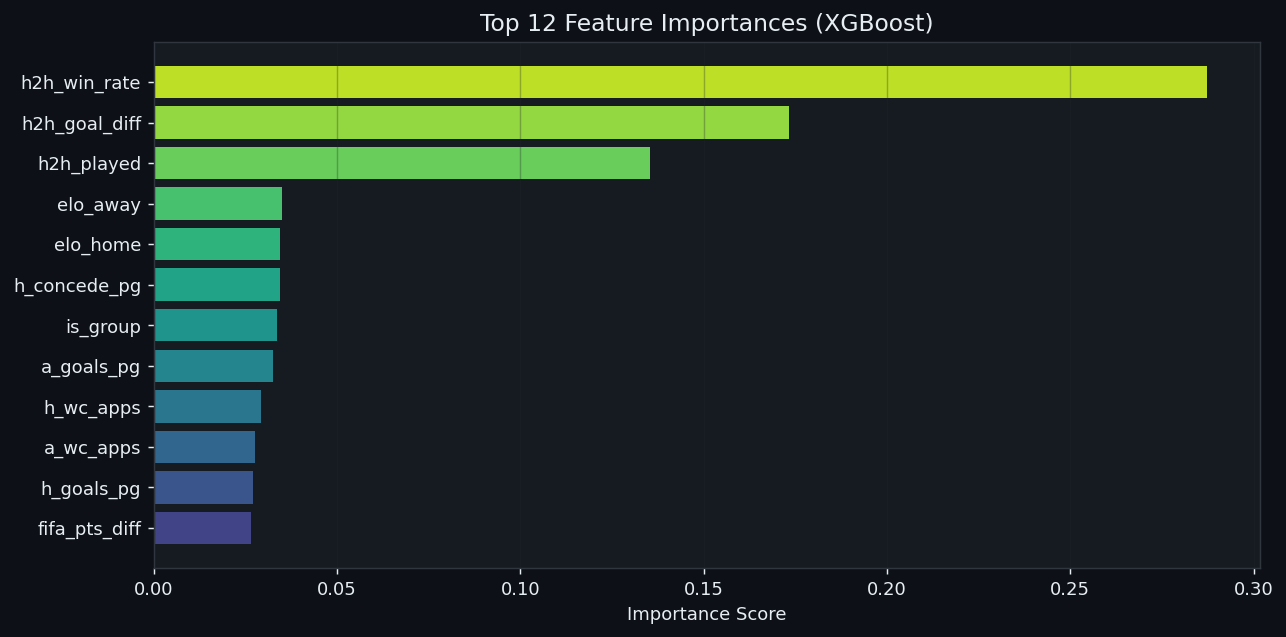


Top 5 most predictive features:
  h2h_win_rate                    0.2874
  h2h_goal_diff                   0.1732
  h2h_played                      0.1354
  elo_away                        0.0349
  elo_home                        0.0345


In [14]:
# ── Cell 4.4 ── Feature importance (from underlying XGBoost estimator)
xgb_base = models["XGBoost"].calibrated_classifiers_[0].estimator
fi = pd.Series(xgb_base.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(fi.index[:12][::-1], fi.values[:12][::-1],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, 12)))
ax.set_title("Top 12 Feature Importances (XGBoost)", fontsize=13, color="#e6edf3")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 most predictive features:")
for feat, val in fi.head(5).items():
    print(f"  {feat:30s}  {val:.4f}")


In [15]:
# ── Cell 4.5 ── Cross-validated accuracy summary
print("5-Fold Cross-Validation Accuracy (full dataset)\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, res in results.items():
    scores = cross_val_score(res["model"], scaler.transform(X), y, cv=cv, scoring="accuracy")
    print(f"  {name:25s}  mean={scores.mean():.3f}  std={scores.std():.3f}")
print()

print("Test-set classification report (best model):")
print(classification_report(y_test, BEST_MODEL.predict(X_test_s),
                             target_names=["Home Win","Draw","Away Win"]))


5-Fold Cross-Validation Accuracy (full dataset)

  Logistic Regression        mean=0.747  std=0.008
  Random Forest              mean=0.816  std=0.017
  XGBoost                    mean=0.813  std=0.028

Test-set classification report (best model):
              precision    recall  f1-score   support

    Home Win       0.75      0.95      0.84        55
        Draw       1.00      0.54      0.70        28
    Away Win       0.80      0.78      0.79        45

    accuracy                           0.80       128
   macro avg       0.85      0.75      0.77       128
weighted avg       0.82      0.80      0.79       128



In [16]:
# ── Cell 4.6 ── Core prediction function used by the simulator
def predict_match(home, away, is_group=True):
    """Return (p_home_win, p_draw, p_away_win) for a match."""
    h2h_feat = get_h2h_features(home, away)
    ht_feat  = get_team_wc_features(home)
    at_feat  = get_team_wc_features(away)
    h_rank   = get_rank_row(home)
    a_rank   = get_rank_row(away)

    feat = np.array([[
        elo[home] - elo[away],
        elo[home], elo[away],
        h_rank["fifa_points"] - a_rank["fifa_points"],
        a_rank["fifa_rank"]   - h_rank["fifa_rank"],
        h2h_feat["h2h_played"],
        h2h_feat["h2h_win_rate"],
        h2h_feat["h2h_goal_diff"],
        ht_feat["wc_apps"], at_feat["wc_apps"],
        ht_feat["goals_per_game"], at_feat["goals_per_game"],
        ht_feat["concede_per_game"], at_feat["concede_per_game"],
        ht_feat["win_rate_wc"], at_feat["win_rate_wc"],
        int(is_group),
        # NOTE: "year" is excluded from FEATURE_COLS during training, so omit it here
    ]])
    feat_s = scaler.transform(feat)
    proba  = BEST_MODEL.predict_proba(feat_s)[0]
    return proba[0], proba[1], proba[2]   # home_win, draw, away_win

# Quick sanity check
print("Argentina vs France  :", tuple(round(p,3) for p in predict_match('Argentina','France', False)))
print("Brazil vs Morocco    :", tuple(round(p,3) for p in predict_match('Brazil','Morocco', True)))
print("USA vs Paraguay      :", tuple(round(p,3) for p in predict_match('United States','Paraguay', True)))


Argentina vs France  : (np.float64(0.427), np.float64(0.214), np.float64(0.36))
Brazil vs Morocco    : (np.float64(1.0), np.float64(0.0), np.float64(0.0))
USA vs Paraguay      : (np.float64(0.995), np.float64(0.0), np.float64(0.005))


---
## 5. Group Stage Simulation

For each simulation we:
1. Play all 72 group-stage matches with probabilistic outcomes
2. Award **3 pts (win), 1 pt (draw), 0 pts (loss)**
3. Simulate goals using team-strength-adjusted Poisson distributions
4. Break ties by goal difference, then goals scored
5. Top 2 teams from each group advance + 8 best 3rd-place teams (48-team WC format)

In [17]:
# ── Cell 5.1 ── Goal model: Poisson expected goals based on strength
# λ_home = base_lambda * (home_attack / away_defence)
# base_lambda calibrated from historical WC data

BASE_LAMBDA_HOME = 1.35   # avg goals for home team in WC group stage
BASE_LAMBDA_AWAY = 1.05

def expected_goals(home, away):
    """Return (lambda_home, lambda_away) using relative strength."""
    hs  = team_strength.get(home, {}).get("strength", 0.3)
    as_ = team_strength.get(away, {}).get("strength", 0.3)
    ratio = (hs + 0.05) / (as_ + 0.05)
    lam_h = BASE_LAMBDA_HOME * ratio ** 0.6
    lam_a = BASE_LAMBDA_AWAY / (ratio ** 0.4)
    return max(lam_h, 0.2), max(lam_a, 0.2)

def simulate_match_score(home, away, allow_draw=True):
    """Return (home_goals, away_goals). In KO rounds draw triggers ET+penalties."""
    lh, la = expected_goals(home, away)
    hg = np.random.poisson(lh)
    ag = np.random.poisson(la)
    if not allow_draw and hg == ag:
        # Extra time — slight edge to higher-ranked team
        p_home, _, p_away = predict_match(home, away, is_group=False)
        return (1, 0) if random.random() < p_home / (p_home + p_away) else (0, 1)
    return hg, ag

# Test
for _ in range(5):
    h, a = simulate_match_score("Argentina","France")
    print(f"  Argentina {h}–{a} France")


  Argentina 2–1 France
  Argentina 0–0 France
  Argentina 3–2 France
  Argentina 0–0 France
  Argentina 1–1 France


In [18]:
# ── Cell 5.2 ── Single group-stage simulation function
def simulate_group(group_letter, group_teams):
    """Simulate one group, return standings as list of dicts sorted by points."""
    standings = {t: {"pts":0, "gf":0, "ga":0, "gd":0, "w":0, "d":0, "l":0}
                 for t in group_teams}

    for i, home in enumerate(group_teams):
        for away in group_teams[i+1:]:
            hg, ag = simulate_match_score(home, away, allow_draw=True)
            standings[home]["gf"] += hg; standings[home]["ga"] += ag
            standings[away]["gf"] += ag; standings[away]["ga"] += hg
            standings[home]["gd"] += hg - ag; standings[away]["gd"] += ag - hg
            if hg > ag:
                standings[home]["pts"] += 3; standings[home]["w"] += 1; standings[away]["l"] += 1
            elif hg < ag:
                standings[away]["pts"] += 3; standings[away]["w"] += 1; standings[home]["l"] += 1
            else:
                standings[home]["pts"] += 1; standings[home]["d"] += 1
                standings[away]["pts"] += 1; standings[away]["d"] += 1

    # Sort: pts → gd → gf → elo tiebreaker
    sorted_teams = sorted(
        standings.items(),
        key=lambda x: (x[1]["pts"], x[1]["gd"], x[1]["gf"],
                       team_strength.get(x[0],{}).get("strength",0)),
        reverse=True
    )
    result = []
    for pos, (team, stats) in enumerate(sorted_teams):
        result.append({"team": team, "group": group_letter, "pos": pos+1, **stats})
    return result

# Demo: simulate Group A
demo = simulate_group("A", GROUPS["A"])
print("Demo — Group A simulation:")
print(f"  {'Team':20s}  Pts  GD  GF  GA")
for row in demo:
    print(f"  {row['team']:20s}  {row['pts']:3d}  {row['gd']:+3d}  {row['gf']:3d}  {row['ga']:3d}")


Demo — Group A simulation:
  Team                  Pts  GD  GF  GA
  Jordan                  9   +3    3    0
  Algeria                 4   +0    3    3
  Austria                 3   +1    4    3
  Argentina               1   -4    1    5


In [19]:
# ── Cell 5.3 ── Full group stage simulation (N_SIMULATIONS runs)
# Track: how often each team finishes 1st, 2nd, 3rd, qualifies

qualify_counts  = defaultdict(int)   # times team qualified (1st or 2nd)
group1st_counts = defaultdict(int)
group2nd_counts = defaultdict(int)
group3rd_counts = defaultdict(int)   # best third-place
group_pts_sum   = defaultdict(float) # cumulative points for avg

print(f"🔄 Running {N_SIMULATIONS:,} group-stage simulations...")

for sim_i in tqdm(range(N_SIMULATIONS)):
    # Simulate all 12 groups
    all_first  = []
    all_second = []
    all_thirds = []

    for letter, teams in GROUPS.items():
        grp_result = simulate_group(letter, teams)
        all_first.append(grp_result[0]["team"])
        all_second.append(grp_result[1]["team"])
        third_row = grp_result[2]
        all_thirds.append({**third_row})

    # Best 8 third-place teams qualify
    all_thirds_sorted = sorted(all_thirds,
                                key=lambda x: (x["pts"], x["gd"], x["gf"],
                                               team_strength.get(x["team"],{}).get("strength",0)),
                                reverse=True)
    best8_thirds = [r["team"] for r in all_thirds_sorted[:8]]

    qualifiers = set(all_first) | set(all_second) | set(best8_thirds)

    for t in all_first:   group1st_counts[t] += 1
    for t in all_second:  group2nd_counts[t] += 1
    for t in best8_thirds: group3rd_counts[t] += 1
    for t in qualifiers:   qualify_counts[t] += 1

qualify_pct  = {t: qualify_counts[t]  / N_SIMULATIONS * 100 for t in ALL_2026_TEAMS}
group1st_pct = {t: group1st_counts[t] / N_SIMULATIONS * 100 for t in ALL_2026_TEAMS}

print(f"\n✅ Done. Qualification probabilities (top 20):")
qdf = pd.DataFrame([{"team": t, "qualify_%": round(qualify_pct[t],1),
                      "win_group_%": round(group1st_pct[t],1)}
                    for t in ALL_2026_TEAMS]).sort_values("qualify_%", ascending=False).head(20)
display(qdf.reset_index(drop=True))


🔄 Running 50,000 group-stage simulations...


100%|██████████| 50000/50000 [00:25<00:00, 1937.74it/s]


✅ Done. Qualification probabilities (top 20):


,team,qualify_%,win_group_%
0,Brazil,96.6,67.3
1,Belgium,95.0,63.9
2,France,94.8,66.5
3,Argentina,92.1,55.8
4,Netherlands,92.0,52.5
5,Spain,90.0,52.7
6,Croatia,89.7,44.8
7,England,89.4,41.5
8,Australia,87.7,37.2
9,Türkiye,87.7,34.7


---
## 6. Knockout Stage Simulation (Monte Carlo)

We simulate the full knockout bracket for each of the `N_SIMULATIONS` tournaments and track:
- Round-of-32 through Final appearance rates
- Championship win percentage per team
- Runner-up & semi-final appearance rates

> **2026 Format:** 48 teams → R32 (32 matches) → R16 → QF → SF → 3rd-place → Final

In [20]:
# ── Cell 6.1 ── Single knockout tournament simulator
def simulate_knockout_tournament(group_results_by_letter):
    """
    Given {group_letter: [ranked team list]}, run the full KO bracket.
    Returns {team: {'r32': bool, 'r16': bool, 'qf': bool, 'sf': bool,
                    'final': bool, 'winner': bool, 'runner_up': bool}}
    """
    # 1. Qualify: top-2 from each group + best 8 thirds
    all_first, all_second, all_thirds = [], [], []
    for letter, standings in group_results_by_letter.items():
        all_first.append(standings[0])
        all_second.append(standings[1])
        all_thirds.append(standings[2])

    best8 = sorted(all_thirds,
                   key=lambda x: (x["pts"], x["gd"], x["gf"],
                                  team_strength.get(x["team"],{}).get("strength",0)),
                   reverse=True)[:8]

    r32_teams = [s["team"] for s in all_first + all_second + best8]
    random.shuffle(r32_teams)   # random bracket draw

    results_track = {t: {"r32":False,"r16":False,"qf":False,"sf":False,
                         "final":False,"winner":False,"runner_up":False}
                     for t in r32_teams}

    def play_round(teams):
        winners = []
        for i in range(0, len(teams), 2):
            h, a = teams[i], teams[i+1]
            hg, ag = simulate_match_score(h, a, allow_draw=False)
            winners.append(h if hg > ag else a)
        return winners

    # R32
    r16 = play_round(r32_teams)
    for t in r32_teams: results_track[t]["r32"] = True

    # R16
    qf = play_round(r16)
    for t in r16: results_track[t]["r16"] = True

    # QF
    sf = play_round(qf)
    for t in qf: results_track[t]["qf"] = True

    # SF
    final_teams = play_round(sf)
    losers = [t for t in sf if t not in final_teams]
    for t in sf: results_track[t]["sf"] = True

    # 3rd-place (tracking only — doesn't affect bracket)
    _ = play_round(losers)

    # Final
    champion = play_round(final_teams)[0]
    runner_up = [t for t in final_teams if t != champion][0]
    for t in final_teams: results_track[t]["final"] = True
    results_track[champion]["winner"]    = True
    results_track[runner_up]["runner_up"] = True

    return results_track

print("✅ Knockout simulator ready.")


✅ Knockout simulator ready.


In [21]:
# ── Cell 6.2 ── Full Monte Carlo simulation: group + knockout
stage_counts = {
    t: {"r32":0,"r16":0,"qf":0,"sf":0,"final":0,"winner":0,"runner_up":0}
    for t in ALL_2026_TEAMS
}

print(f"🔄 Running full {N_SIMULATIONS:,} tournament simulations (group + KO)...")

for _ in tqdm(range(N_SIMULATIONS)):
    # Simulate all groups
    group_results = {}
    for letter, teams in GROUPS.items():
        group_results[letter] = simulate_group(letter, teams)

    ko_results = simulate_knockout_tournament(group_results)
    for team, stages in ko_results.items():
        for stage, reached in stages.items():
            if reached:
                stage_counts[team][stage] += 1

# Convert to percentages
win_probs = {}
for team in ALL_2026_TEAMS:
    win_probs[team] = {
        stage: round(stage_counts[team][stage] / N_SIMULATIONS * 100, 2)
        for stage in ["r32","r16","qf","sf","final","winner","runner_up"]
    }
    win_probs[team]["qualify"] = round(qualify_pct[team], 2)

print("\n✅ Full tournament simulation complete!")


🔄 Running full 50,000 tournament simulations (group + KO)...


100%|██████████| 50000/50000 [2:02:55<00:00,  6.78it/s]


✅ Full tournament simulation complete!


In [22]:
# ── Cell 6.3 ── Full probability table
prob_df = pd.DataFrame([
    {"Team": t, "Qualify%": wp["qualify"], "R32%": wp["r32"],
     "R16%": wp["r16"], "QF%": wp["qf"], "SF%": wp["sf"],
     "Final%": wp["final"], "Runner-Up%": wp["runner_up"], "Win%": wp["winner"]}
    for t, wp in win_probs.items()
]).sort_values("Win%", ascending=False).reset_index(drop=True)

prob_df.index += 1   # 1-based ranking

print("🏆 FULL WORLD CUP 2026 WIN PROBABILITY TABLE\n")
display(prob_df.style
    .background_gradient(subset=["Win%","Final%","SF%"], cmap="YlOrRd")
    .format({col: "{:.1f}" for col in ["Qualify%","R32%","R16%","QF%","SF%","Final%","Runner-Up%","Win%"]})
    .set_caption("Probabilities derived from 50,000 Monte Carlo simulations"))


🏆 FULL WORLD CUP 2026 WIN PROBABILITY TABLE



,Team,Qualify%,R32%,R16%,QF%,SF%,Final%,Runner-Up%,Win%
1,France,94.8,95.0,64.7,43.0,27.7,17.6,7.0,10.6
2,Brazil,96.5,96.4,64.2,41.7,26.1,16.0,6.5,9.5
3,Netherlands,92.0,91.8,61.8,39.9,25.2,15.3,6.2,9.1
4,Germany,82.0,81.9,54.9,35.9,22.9,14.2,5.5,8.8
5,Argentina,92.1,92.0,60.0,38.0,23.3,13.8,5.8,8.1
6,Spain,90.0,90.4,57.6,35.2,20.9,11.9,5.3,6.6
7,England,89.4,89.2,54.4,32.2,18.3,9.9,4.8,5.1
8,Belgium,95.0,95.2,56.4,32.0,17.4,9.1,4.6,4.5
9,Croatia,89.7,90.0,51.2,28.0,14.7,7.5,3.9,3.5
10,Portugal,79.2,79.2,45.0,24.6,13.0,6.5,3.5,3.1


---
## 7. Tournament Win Probabilities

Deep-dive into who wins the cup, who reaches the final, and how the probabilities evolved from 2022 rankings to the 2026 rankings.

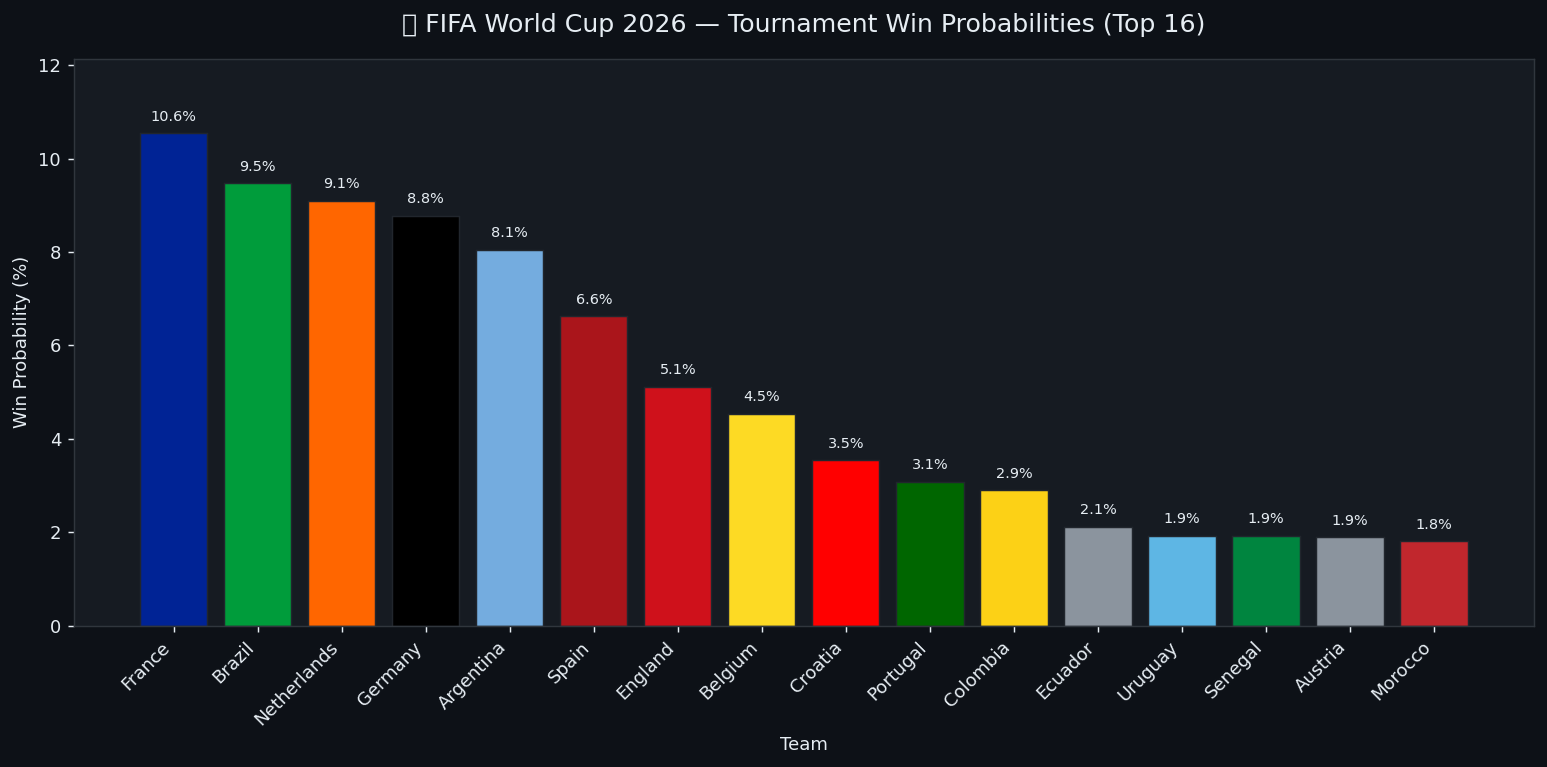

In [23]:
# ── Cell 7.1 ── Win probability bar chart (top 16 teams)
top16 = prob_df.head(16)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in top16["Team"]]
bars = ax.bar(top16["Team"], top16["Win%"], color=colors, edgecolor="#21262d", linewidth=0.8)

for bar, val in zip(bars, top16["Win%"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#e6edf3")

ax.set_title("⚽ FIFA World Cup 2026 — Tournament Win Probabilities (Top 16)", fontsize=14, pad=15)
ax.set_xlabel("Team"); ax.set_ylabel("Win Probability (%)")
ax.set_ylim(0, top16["Win%"].max() * 1.15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


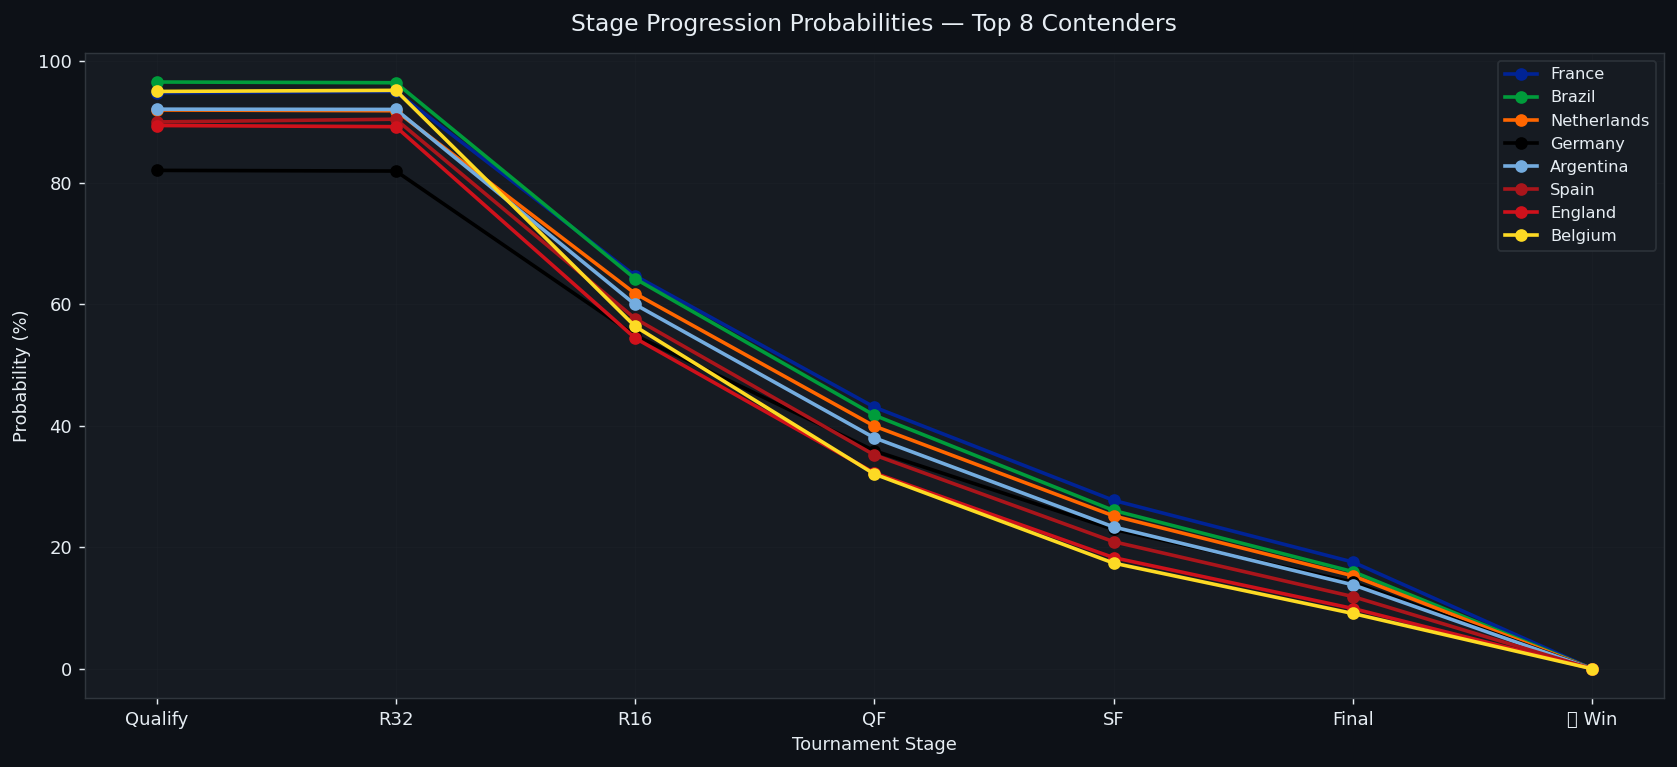

In [24]:
# ── Cell 7.2 ── Stage-by-stage funnel for top 8 teams
top8_teams = prob_df.head(8)["Team"].tolist()
stages = ["Qualify%","R32%","R16%","QF%","SF%","Final%","Win%"]
stage_labels = ["Qualify","R32","R16","QF","SF","Final","🏆 Win"]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(stages))

for i, team in enumerate(top8_teams):
    vals = [win_probs[team].get(s.replace("%","").lower(), 0)
            if s != "Qualify%" else win_probs[team]["qualify"]
            for s in stages]
    color = TEAM_COLORS.get(team, plt.cm.tab10(i/8))
    ax.plot(x, vals, marker="o", linewidth=2, markersize=6,
            label=team, color=color)

ax.set_xticks(x); ax.set_xticklabels(stage_labels)
ax.set_title("Stage Progression Probabilities — Top 8 Contenders", fontsize=13, pad=12)
ax.set_ylabel("Probability (%)"); ax.set_xlabel("Tournament Stage")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


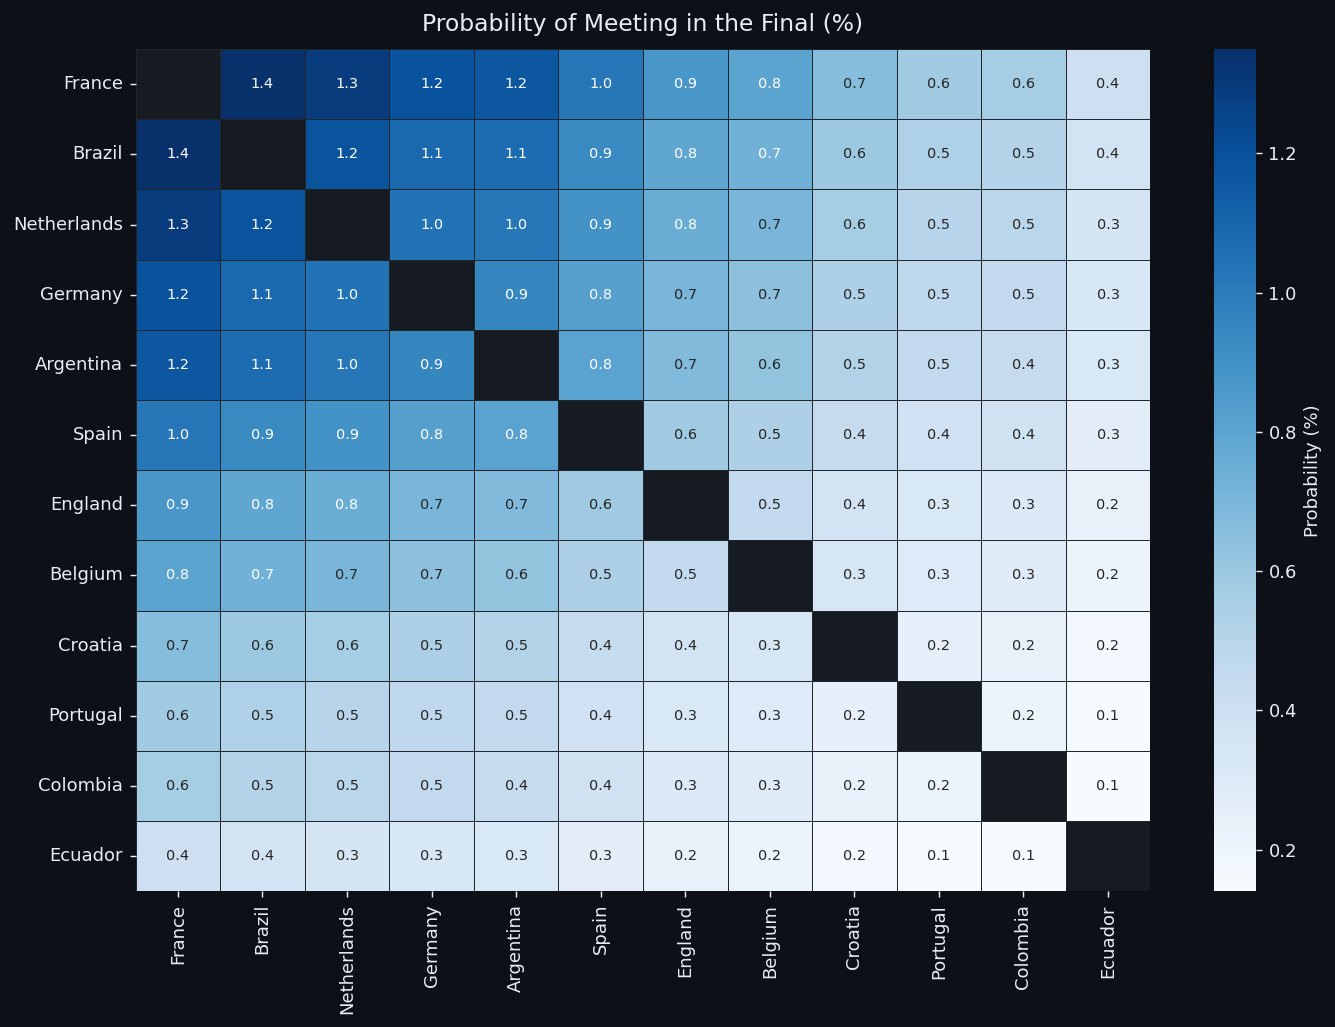

In [25]:
# ── Cell 7.3 ── Head-to-head Final matchup heatmap (simulated)
# Probability that team A meets team B in the final
FINAL_MATCHUP = defaultdict(lambda: defaultdict(int))
top12_teams = prob_df.head(12)["Team"].tolist()

# Re-use stage_counts since we tracked the finalist data — approximate via:
# P(A vs B in final) ≈ P(A wins) * P(B runner-up) + P(B wins) * P(A runner-up)
final_matrix = np.zeros((len(top12_teams), len(top12_teams)))
for i, t1 in enumerate(top12_teams):
    for j, t2 in enumerate(top12_teams):
        if i == j:
            final_matrix[i][j] = np.nan
        else:
            p = (win_probs[t1]["winner"]/100 * win_probs[t2]["runner_up"]/100 +
                 win_probs[t2]["winner"]/100 * win_probs[t1]["runner_up"]/100) * 100
            final_matrix[i][j] = round(p, 2)

fdf = pd.DataFrame(final_matrix, index=top12_teams, columns=top12_teams)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.isnan(final_matrix)
sns.heatmap(fdf, annot=True, fmt=".1f", cmap="Blues", mask=mask,
            linewidths=0.5, linecolor="#21262d",
            annot_kws={"size": 8}, ax=ax,
            cbar_kws={"label": "Probability (%)"})
ax.set_title("Probability of Meeting in the Final (%)", fontsize=13, pad=10)
plt.tight_layout()
plt.show()


---
## 8. Dark Horse Analysis

A "dark horse" is a team whose **simulated win probability is significantly higher** than what their FIFA ranking alone would predict.  
We compute a **Dark Horse Score = (simulated win prob) / (naive rank-based expected win prob)**.

In [26]:
# ── Cell 8.1 ── Compute naive baseline from FIFA ranking
# Naive baseline: P(win) proportional to FIFA points (sum to 1 across 48 teams)
total_pts = sum(team_strength[t]["fifa_points"] for t in ALL_2026_TEAMS)
naive_win_prob = {t: team_strength[t]["fifa_points"] / total_pts * 100 for t in ALL_2026_TEAMS}

# Dark horse score
dark_horse_df = pd.DataFrame([{
    "Team":           t,
    "Group":          GROUP_MAP[t],
    "FIFA_Rank":      int(team_strength[t]["fifa_rank"]),
    "Simulated_Win%": round(win_probs[t]["winner"], 2),
    "Naive_Win%":     round(naive_win_prob[t], 2),
    "DH_Score":       round(win_probs[t]["winner"] / (naive_win_prob[t] + 1e-6), 2),
    "SF%":            round(win_probs[t]["sf"], 2),
    "Qualify%":       round(win_probs[t]["qualify"], 2),
} for t in ALL_2026_TEAMS]).sort_values("DH_Score", ascending=False)

# Filter: only teams ranked outside top 10 (i.e., not the favourites)
dark_horses = dark_horse_df[dark_horse_df["FIFA_Rank"] > 10].head(10).reset_index(drop=True)
dark_horses.index += 1

print("🌟 TOP 10 DARK HORSE CANDIDATES\n")
print("DH_Score > 1.0 means the model rates this team HIGHER than their FIFA rank suggests\n")
display(dark_horses.style
    .background_gradient(subset=["DH_Score"], cmap="YlOrRd")
    .format({"DH_Score": "{:.2f}", "Simulated_Win%": "{:.2f}",
             "Naive_Win%": "{:.2f}", "SF%": "{:.2f}", "Qualify%": "{:.1f}"})
    .set_caption("Dark Horse Score = Simulated Win% / Naive Rank-Based Win%"))


🌟 TOP 10 DARK HORSE CANDIDATES

DH_Score > 1.0 means the model rates this team HIGHER than their FIFA rank suggests



,Team,Group,FIFA_Rank,Simulated_Win%,Naive_Win%,DH_Score,SF%,Qualify%
1,Croatia,H,11,3.55,2.29,1.55,14.67,89.7
2,Colombia,G,13,2.90,2.26,1.28,12.95,84.6
3,Ecuador,I,23,2.12,2.13,1.00,9.39,67.6
4,Austria,A,24,1.90,2.13,0.89,9.63,67.8
5,Uruguay,F,16,1.93,2.23,0.87,9.61,77.0
6,Senegal,K,15,1.93,2.25,0.86,8.51,62.4
7,Türkiye,B,22,1.75,2.14,0.82,9.51,87.7
8,Norway,K,31,1.53,2.08,0.74,7.25,59.1
9,Mexico,J,14,1.51,2.25,0.67,8.34,78.3
10,Japan,L,18,1.17,2.21,0.53,7.13,80.0


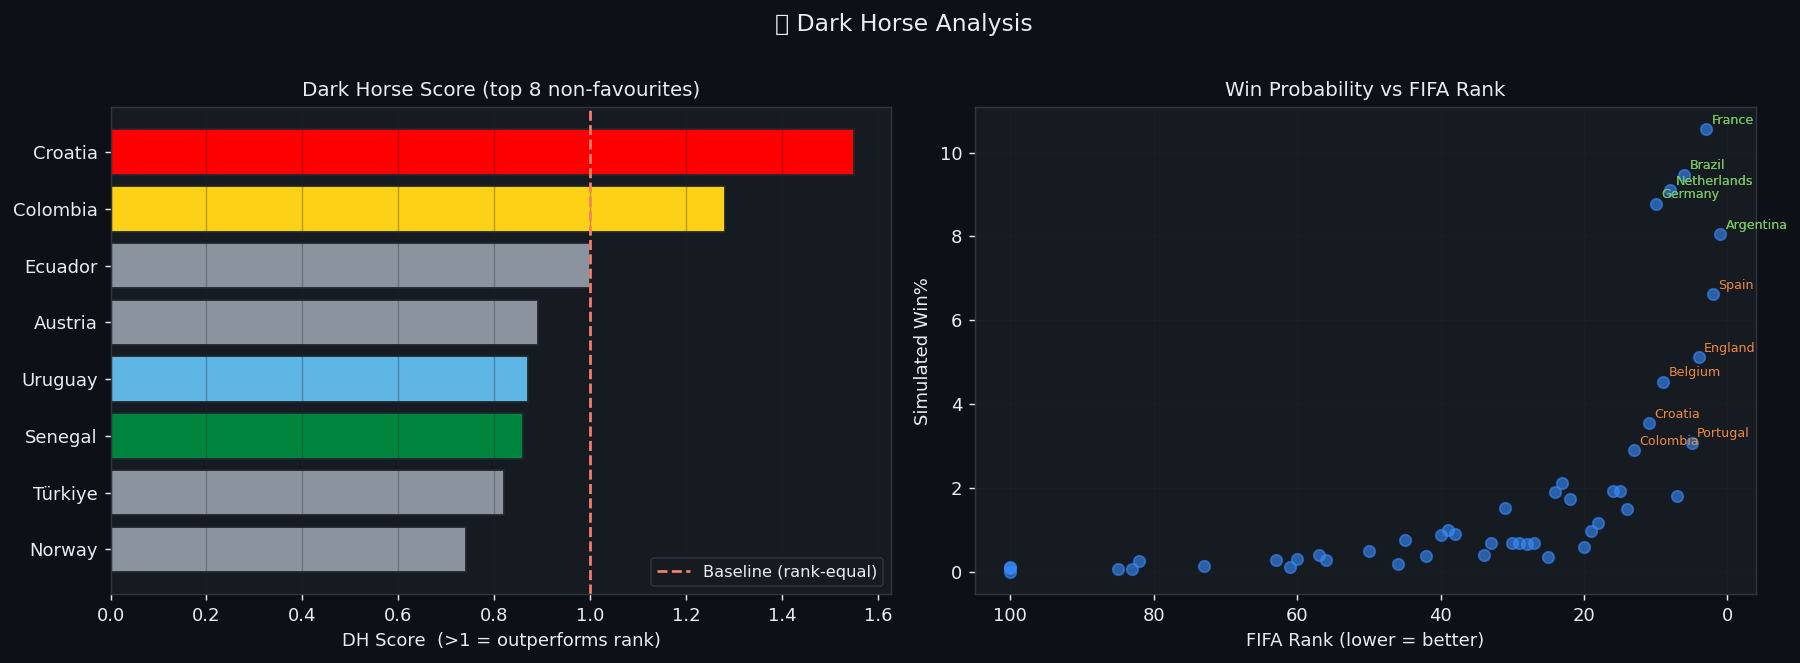

In [27]:
# ── Cell 8.2 ── Dark horse visualisation
top_dh = dark_horse_df[dark_horse_df["FIFA_Rank"] > 10].head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: DH score bar chart
colors_dh = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in top_dh["Team"]]
axes[0].barh(top_dh["Team"][::-1], top_dh["DH_Score"][::-1],
             color=colors_dh[::-1], edgecolor="#21262d")
axes[0].axvline(1.0, color="#f78166", linestyle="--", linewidth=1.5, label="Baseline (rank-equal)")
axes[0].set_title("Dark Horse Score (top 8 non-favourites)", fontsize=11)
axes[0].set_xlabel("DH Score  (>1 = outperforms rank)")
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", alpha=0.3)

# Right: Simulated Win% vs FIFA Rank scatter
x_all = [team_strength[t]["fifa_rank"]      for t in ALL_2026_TEAMS]
y_all = [win_probs[t]["winner"]              for t in ALL_2026_TEAMS]
labels_all = ALL_2026_TEAMS

axes[1].scatter(x_all, y_all, color="#388bfd", alpha=0.6, s=40, zorder=3)
# Annotate top outliers (high win% relative to rank)
outliers = dark_horse_df[(dark_horse_df["DH_Score"] > 1.2) &
                          (dark_horse_df["Simulated_Win%"] > 0.1)]
for _, row in outliers.iterrows():
    axes[1].annotate(row["Team"],
                     (row["FIFA_Rank"], row["Simulated_Win%"]),
                     fontsize=7, color="#f0883e",
                     xytext=(3, 3), textcoords="offset points")
# Also annotate top 5 by win%
for _, row in prob_df.head(5).iterrows():
    axes[1].annotate(row["Team"],
                     (team_strength[row["Team"]]["fifa_rank"], row["Win%"]),
                     fontsize=7, color="#56d364",
                     xytext=(3, 3), textcoords="offset points")
axes[1].set_title("Win Probability vs FIFA Rank", fontsize=11)
axes[1].set_xlabel("FIFA Rank (lower = better)"); axes[1].set_ylabel("Simulated Win%")
axes[1].invert_xaxis()
axes[1].grid(alpha=0.3)

plt.suptitle("🌟 Dark Horse Analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [28]:
# ── Cell 8.3 ── Upset probability matrix for key group-stage matches
upset_pairs = [
    ("Morocco",    "Brazil",   True,  "Group E"),
    ("USA",        "Argentina",True,  "Group A (if met)"),
    ("Japan",      "Netherlands", True, "Group L"),
    ("Senegal",    "France",   True,  "Group K"),
    ("Colombia",   "Portugal", True,  "Group G"),
    ("Korea Republic", "Germany", True, "Group J"),
]

print("⚡ KEY UPSET PROBABILITIES\n")
print(f"{'Underdog':20s}  {'Favourite':15s}  {'Upset%':>8s}  {'Match':>15s}")
print("-" * 65)
for underdog, fav, is_group, matchup in upset_pairs:
    ph, pd_, pa = predict_match(underdog, fav, is_group)
    upset_pct = ph * 100   # underdog listed as home
    print(f"  {underdog:18s}  {fav:15s}  {upset_pct:7.1f}%   {matchup}")


⚡ KEY UPSET PROBABILITIES

Underdog              Favourite          Upset%            Match
-----------------------------------------------------------------
  Morocco             Brazil               0.0%   Group E
  USA                 Argentina            6.9%   Group A (if met)
  Japan               Netherlands          0.0%   Group L
  Senegal             France              97.8%   Group K
  Colombia            Portugal             8.8%   Group G
  Korea Republic      Germany              9.8%   Group J


---
## 9. Top Scorer Predictions

We estimate top-scorer probabilities using:
- Historical WC top-scorer data
- Team's expected goals per match (Poisson model)
- Each team's expected number of matches played (from simulation)
- A prior on top-scorer frequency by team nation

In [29]:
# ── Cell 9.1 ── Historical top scorer data from world_cup.csv
print("Historical World Cup Top Scorers:\n")
top_scorer_hist = wc_hist[["Year","Champion","TopScorrer"]].copy()
display(top_scorer_hist)


Historical World Cup Top Scorers:



,Year,Champion,TopScorrer
0,2022,Argentina,Kylian Mbappé - 8
1,2018,France,Harry Kane - 6
2,2014,Germany,James Rodríguez - 6
3,2010,Spain,"Wesley Sneijder, Thomas Müller... - 5"
4,2006,Italy,Miroslav Klose - 5
5,2002,Brazil,Ronaldo - 8
6,1998,France,Davor Šuker - 6
7,1994,Brazil,"Hristo Stoichkov, Oleg Salenko - 6"
8,1990,West Germany,Salvatore Schillaci - 6
9,1986,Argentina,Gary Lineker - 6


In [30]:
# ── Cell 9.2 ── Expected goals per match per team & expected matches played
team_exp_goals = {}
team_exp_matches = {}

for team in ALL_2026_TEAMS:
    # Expected goals per game when playing as the 'home' side (average across all opponents)
    exp_goals_list = []
    for opp in ALL_2026_TEAMS:
        if opp != team:
            lh, la = expected_goals(team, opp)
            exp_goals_list.append(lh)
    team_exp_goals[team] = np.mean(exp_goals_list)

    # Expected matches: weighted sum across rounds
    # Stage probs from simulation
    wp = win_probs[team]
    # Minimum 3 group games; +1 per KO round
    exp_m = (3 * wp["qualify"]/100 +
             1 * wp["r32"]/100 +
             1 * wp["r16"]/100 +
             1 * wp["qf"]/100 +
             1 * wp["sf"]/100 +
             1 * wp["final"]/100)
    team_exp_matches[team] = max(exp_m, wp["qualify"]/100 * 3)

# Expected total goals for a team across the tournament
team_exp_total_goals = {t: team_exp_goals[t] * team_exp_matches[t]
                        for t in ALL_2026_TEAMS}

top_goal_teams = sorted(team_exp_total_goals.items(), key=lambda x: x[1], reverse=True)
print("🎯 Expected Team Goals in Tournament (Top 15):\n")
for team, goals in top_goal_teams[:15]:
    print(f"  {team:25s}  {goals:.2f} expected goals")


🎯 Expected Team Goals in Tournament (Top 15):

  France                     10.84 expected goals
  Brazil                     10.29 expected goals
  Netherlands                10.00 expected goals
  Argentina                  9.89 expected goals
  Spain                      9.02 expected goals
  Belgium                    8.69 expected goals
  Germany                    8.63 expected goals
  England                    8.45 expected goals
  Croatia                    7.82 expected goals
  Portugal                   6.91 expected goals
  Colombia                   6.82 expected goals
  Türkiye                    6.58 expected goals
  Morocco                    6.26 expected goals
  Uruguay                    6.12 expected goals
  Mexico                     6.01 expected goals


In [31]:
# ── Cell 9.3 ── Top scorer simulation using per-game Poisson
# Heuristic: we model the tournament's top scorer as a player from the
# highest-scoring team; top teams' expected scorer = lambda * tournament_games

# Known current top strikers per country (2026 era)
TOP_STRIKERS = {
    "Argentina":      "Lautaro Martínez",
    "France":         "Kylian Mbappé",
    "Brazil":         "Vinicius Jr.",
    "England":        "Harry Kane",
    "Spain":          "Álvaro Morata",
    "Portugal":       "Cristiano Ronaldo",
    "Germany":        "Kai Havertz",
    "Netherlands":    "Memphis Depay",
    "Morocco":        "Youssef En-Nesyri",
    "Belgium":        "Romelu Lukaku",
    "Croatia":        "Ivan Perišić",
    "Uruguay":        "Darwin Núñez",
    "United States":  "Christian Pulisic",
    "Japan":          "Ayase Ueda",
    "Senegal":        "Sadio Mané",
    "Colombia":       "Luis Díaz",
    "Mexico":         "Raúl Jiménez",
    "Switzerland":    "Breel Embolo",
    "Korea Republic": "Son Heung-min",
}

N_SCORER_SIMS = 20_000
top_scorer_wins = defaultdict(int)

print(f"🔄 Simulating top-scorer race ({N_SCORER_SIMS:,} iterations)...")
for _ in range(N_SCORER_SIMS):
    player_goals = {}
    for team, player in TOP_STRIKERS.items():
        if team not in ALL_2026_TEAMS:
            continue
        lam = team_exp_goals.get(team, 1.0)
        # Expected matches for team in this sim (use distribution)
        # Approximate: sample matches from poisson of expected_matches
        exp_m = team_exp_matches.get(team, 3)
        n_games = max(3, np.random.poisson(exp_m))
        # Player scores a fraction of team goals (assume 25–35% share)
        share = np.random.uniform(0.22, 0.38)
        goals = sum(np.random.poisson(lam * share) for _ in range(n_games))
        player_goals[player] = goals

    if player_goals:
        winner = max(player_goals, key=player_goals.get)
        top_scorer_wins[winner] += 1

scorer_probs = pd.DataFrame([
    {"Player": p, "Team": next((t for t, pl in TOP_STRIKERS.items() if pl == p), "?"),
     "TopScorer%": round(v / N_SCORER_SIMS * 100, 2)}
    for p, v in top_scorer_wins.items()
]).sort_values("TopScorer%", ascending=False).reset_index(drop=True)
scorer_probs.index += 1

print("\n🥇 TOP SCORER PROBABILITY TABLE\n")
display(scorer_probs)


🔄 Simulating top-scorer race (20,000 iterations)...

🥇 TOP SCORER PROBABILITY TABLE



,Player,Team,TopScorer%
1,Kylian Mbappé,France,15.35
2,Lautaro Martínez,Argentina,12.58
3,Vinicius Jr.,Brazil,12.32
4,Memphis Depay,Netherlands,9.41
5,Álvaro Morata,Spain,8.00
6,Harry Kane,England,7.03
7,Kai Havertz,Germany,6.87
8,Romelu Lukaku,Belgium,5.95
9,Ivan Perišić,Croatia,4.38
10,Cristiano Ronaldo,Portugal,4.20


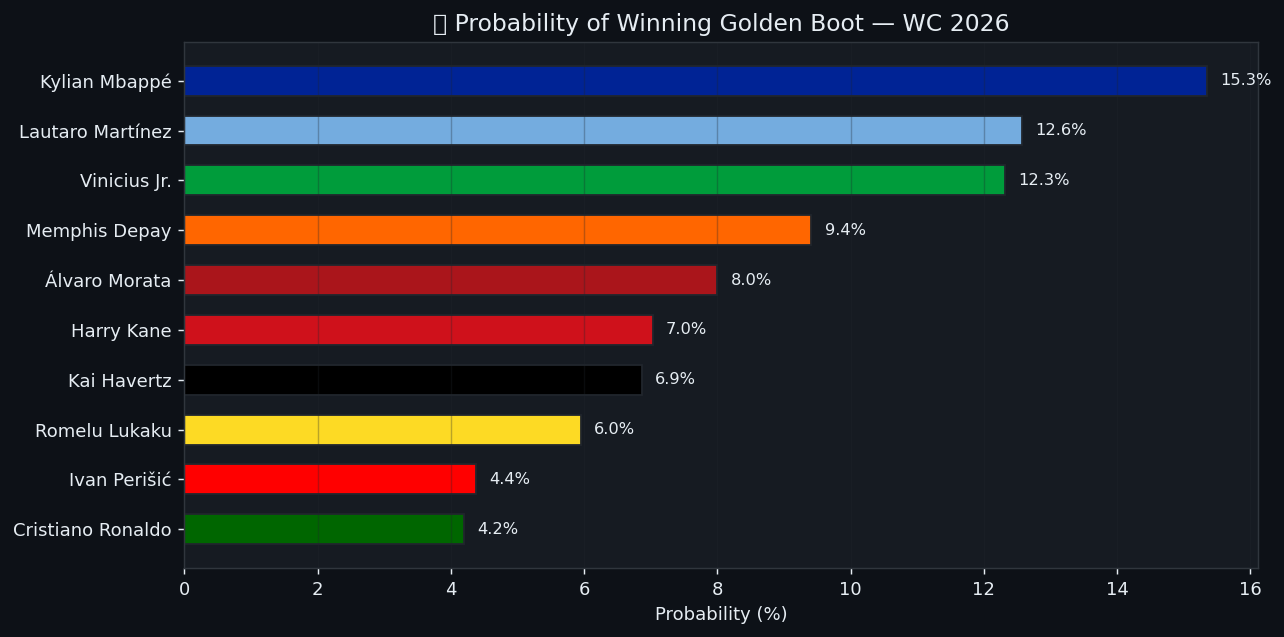

In [32]:
# ── Cell 9.4 ── Top scorer visualisation
fig, ax = plt.subplots(figsize=(10, 5))
top_sc = scorer_probs.head(10)
colors_sc = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in top_sc["Team"]]
bars = ax.barh(top_sc["Player"][::-1], top_sc["TopScorer%"][::-1],
               color=colors_sc[::-1], edgecolor="#21262d", height=0.6)
for bar, val in zip(bars, top_sc["TopScorer%"][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("🥇 Probability of Winning Golden Boot — WC 2026", fontsize=13)
ax.set_xlabel("Probability (%)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 10. Additional Predictions & Stats

Beyond the winner and top scorer, we compute a range of additional predictions that make the tournament analysis complete.

In [33]:
# ── Cell 10.1 ── Best defensive teams (fewest expected goals conceded per game)
team_exp_concede = {}
for team in ALL_2026_TEAMS:
    exp_concede_list = []
    for opp in ALL_2026_TEAMS:
        if opp != team:
            lh_opp, _ = expected_goals(opp, team)   # opponent is now "home"
            exp_concede_list.append(lh_opp)
    team_exp_concede[team] = np.mean(exp_concede_list)

def_df = pd.DataFrame([{"Team": t, "Exp_Goals_Conceded_pg": round(team_exp_concede[t], 3),
                         "FIFA_Rank": int(team_strength[t]["fifa_rank"])}
                        for t in ALL_2026_TEAMS]).sort_values("Exp_Goals_Conceded_pg").reset_index(drop=True)
def_df.index += 1

print("🛡️ BEST DEFENSIVE TEAMS (lowest expected goals conceded per game)\n")
display(def_df.head(12))


🛡️ BEST DEFENSIVE TEAMS (lowest expected goals conceded per game)



,Team,Exp_Goals_Conceded_pg,FIFA_Rank
1,France,0.933,3
2,Argentina,0.967,1
3,Netherlands,0.969,8
4,Brazil,0.987,6
5,Germany,1.004,10
6,Spain,1.025,2
7,England,1.063,4
8,Belgium,1.084,9
9,Portugal,1.118,5
10,Croatia,1.121,11


In [34]:
# ── Cell 10.2 ── Groups of Death: expected total goals and competitive balance
group_stats = {}
for letter, teams in GROUPS.items():
    avg_strength = np.mean([team_strength[t]["strength"] for t in teams])
    strength_std  = np.std([team_strength[t]["strength"] for t in teams])
    avg_rank      = np.mean([team_strength[t]["fifa_rank"] for t in teams])
    # Lower std = tighter group = more competitive
    group_stats[letter] = {
        "teams":           ", ".join(teams),
        "avg_strength":    round(avg_strength, 4),
        "strength_std":    round(strength_std, 4),
        "avg_fifa_rank":   round(avg_rank, 1),
        "competitiveness": round(1.0 / (strength_std + 0.01), 2)
    }

gdf = pd.DataFrame([{"Group": k, **v} for k, v in group_stats.items()])
gdf = gdf.sort_values("avg_strength", ascending=False).reset_index(drop=True)
gdf.index += 1

print("💀 GROUPS OF DEATH (sorted by average team strength)\n")
display(gdf[["Group","teams","avg_strength","avg_fifa_rank","competitiveness"]].style
    .background_gradient(subset=["avg_strength"], cmap="OrRd")
    .background_gradient(subset=["competitiveness"], cmap="Blues")
    .format({"avg_strength": "{:.4f}", "avg_fifa_rank": "{:.1f}",
             "competitiveness": "{:.2f}"})
    .set_caption("Competitiveness = 1 / std(team strengths) — higher means tighter group"))


💀 GROUPS OF DEATH (sorted by average team strength)



,Group,teams,avg_strength,avg_fifa_rank,competitiveness
1,K,"France, Iraq, Norway, Senegal",0.6281,26.2,4.19
2,L,"Japan, Netherlands, Sweden, Tunisia",0.6020,27.5,4.71
3,A,"Algeria, Argentina, Austria, Jordan",0.5906,29.0,4.64
4,H,"Croatia, England, Ghana, Panama",0.5764,30.5,5.14
5,G,"Colombia, Congo DR, Portugal, Uzbekistan",0.5678,28.2,7.81
6,I,"Curaçao, Côte d'Ivoire, Ecuador, Germany",0.5611,37.0,4.77
7,E,"Brazil, Haiti, Morocco, Scotland",0.5472,34.5,3.92
8,F,"Cape Verde, Saudi Arabia, Spain, Uruguay",0.5089,44.8,3.90
9,J,"Czechia, Korea Republic, Mexico, South Africa",0.4931,34.5,10.92
10,C,"Belgium, Egypt, IR Iran, New Zealand",0.4807,35.8,5.32


In [35]:
# ── Cell 10.3 ── Who benefits most from draw luck? Easiest / hardest brackets
# For each team, avg strength of opponents in group
team_group_difficulty = {}
for team in ALL_2026_TEAMS:
    grp = GROUP_MAP[team]
    opponents = [t for t in GROUPS[grp] if t != team]
    avg_opp_strength = np.mean([team_strength[o]["strength"] for o in opponents])
    team_group_difficulty[team] = avg_opp_strength

diff_df = pd.DataFrame([{
    "Team": t, "Group": GROUP_MAP[t],
    "Avg_Opp_Strength": round(team_group_difficulty[t], 4),
    "Team_Strength":    round(team_strength[t]["strength"], 4),
    "Strength_Advantage": round(team_strength[t]["strength"] - team_group_difficulty[t], 4),
} for t in ALL_2026_TEAMS]).sort_values("Strength_Advantage", ascending=False).reset_index(drop=True)

print("🎯 DRAW LUCK — Teams with biggest strength advantage over group opponents (top 10):\n")
display(diff_df.head(10))
print("\n☠️ Hardest draws — Teams most disadvantaged in their group (bottom 10):\n")
display(diff_df.tail(10))


🎯 DRAW LUCK — Teams with biggest strength advantage over group opponents (top 10):



,Team,Group,Avg_Opp_Strength,Team_Strength,Strength_Advantage
0,France,K,0.5077,0.9891,0.4814
1,Brazil,E,0.4301,0.8987,0.4686
2,Argentina,A,0.4773,0.9306,0.4533
3,Spain,F,0.3978,0.8420,0.4441
4,Netherlands,L,0.4937,0.9269,0.4333
5,Germany,I,0.4573,0.8726,0.4153
6,Belgium,C,0.3863,0.7638,0.3775
7,England,H,0.5052,0.7900,0.2848
8,Türkiye,B,0.3730,0.6056,0.2326
9,Switzerland,D,0.3522,0.5766,0.2245



☠️ Hardest draws — Teams most disadvantaged in their group (bottom 10):



,Team,Group,Avg_Opp_Strength,Team_Strength,Strength_Advantage
38,Jordan,A,0.6566,0.3925,-0.2642
39,New Zealand,C,0.5503,0.2719,-0.2784
40,Saudi Arabia,F,0.5807,0.2933,-0.2875
41,Tunisia,L,0.6787,0.3720,-0.3067
42,Ghana,H,0.6537,0.3444,-0.3093
43,Curaçao,I,0.6409,0.3217,-0.3192
44,United States,B,0.5138,0.1831,-0.3307
45,Cape Verde,F,0.5948,0.2512,-0.3435
46,Iraq,K,0.7151,0.3671,-0.3479
47,Haiti,E,0.6460,0.2510,-0.3950


In [36]:
# ── Cell 10.4 ── Historical host-effect and confederation analysis
conf_wins = wc_hist["Champion"].value_counts()
print("🌎 All-Time WC Champions:\n")
display(wc_hist[["Year","Champion","Runner-Up","TopScorrer"]].to_string(index=False))

print("\n📊 Championships by Country:\n")
for champ, count in conf_wins.items():
    print(f"  {champ:15s}  {'🏆' * count}  ({count}x)")


🌎 All-Time WC Champions:



' Year     Champion      Runner-Up                            TopScorrer\n 2022    Argentina         France                     Kylian Mbappé - 8\n 2018       France        Croatia                        Harry Kane - 6\n 2014      Germany      Argentina                   James Rodríguez - 6\n 2010        Spain    Netherlands Wesley Sneijder, Thomas Müller... - 5\n 2006        Italy         France                    Miroslav Klose - 5\n 2002       Brazil        Germany                           Ronaldo - 8\n 1998       France         Brazil                       Davor Šuker - 6\n 1994       Brazil          Italy    Hristo Stoichkov, Oleg Salenko - 6\n 1990 West Germany      Argentina               Salvatore Schillaci - 6\n 1986    Argentina   West Germany                      Gary Lineker - 6\n 1982        Italy   West Germany                       Paolo Rossi - 6\n 1978    Argentina    Netherlands                      Mario Kempes - 6\n 1974 West Germany    Netherlands                 


📊 Championships by Country:

  Brazil           🏆🏆🏆🏆🏆  (5x)
  Italy            🏆🏆🏆🏆  (4x)
  Argentina        🏆🏆🏆  (3x)
  Germany          🏆🏆  (2x)
  France           🏆🏆  (2x)
  Uruguay          🏆🏆  (2x)
  West Germany     🏆🏆  (2x)
  Spain            🏆  (1x)
  England          🏆  (1x)


In [37]:
# ── Cell 10.5 ── Predicted average goals per group (highest-scoring groups)
group_goal_pred = {}
for letter, teams in GROUPS.items():
    total_lam = 0
    n_matches = 0
    for i, h in enumerate(teams):
        for a in teams[i+1:]:
            lh, la = expected_goals(h, a)
            total_lam += lh + la
            n_matches += 1
    group_goal_pred[letter] = {
        "teams": ", ".join(teams),
        "exp_goals_total": round(total_lam, 2),
        "exp_goals_pg":    round(total_lam / n_matches, 2)
    }

gg_df = pd.DataFrame([{"Group": k, **v} for k, v in group_goal_pred.items()])
gg_df = gg_df.sort_values("exp_goals_total", ascending=False).reset_index(drop=True)
gg_df.index += 1

print("🎯 PREDICTED GOALS BY GROUP\n")
display(gg_df.style
    .background_gradient(subset=["exp_goals_total","exp_goals_pg"], cmap="YlOrRd")
    .format({"exp_goals_total": "{:.2f}", "exp_goals_pg": "{:.2f}"})
    .set_caption("Expected goals across all 6 group-stage matches per group"))


🎯 PREDICTED GOALS BY GROUP



,Group,teams,exp_goals_total,exp_goals_pg
1,B,"Australia, Paraguay, Türkiye, United States",16.16,2.69
2,C,"Belgium, Egypt, IR Iran, New Zealand",16.08,2.68
3,E,"Brazil, Haiti, Morocco, Scotland",15.99,2.67
4,H,"Croatia, England, Ghana, Panama",15.74,2.62
5,L,"Japan, Netherlands, Sweden, Tunisia",15.55,2.59
6,K,"France, Iraq, Norway, Senegal",15.38,2.56
7,A,"Algeria, Argentina, Austria, Jordan",15.26,2.54
8,G,"Colombia, Congo DR, Portugal, Uzbekistan",14.82,2.47
9,J,"Czechia, Korea Republic, Mexico, South Africa",14.55,2.43
10,F,"Cape Verde, Saudi Arabia, Spain, Uruguay",14.06,2.34


---
## 11. Full Visualisation Dashboard

One consolidated multi-panel figure summarising all key predictions.

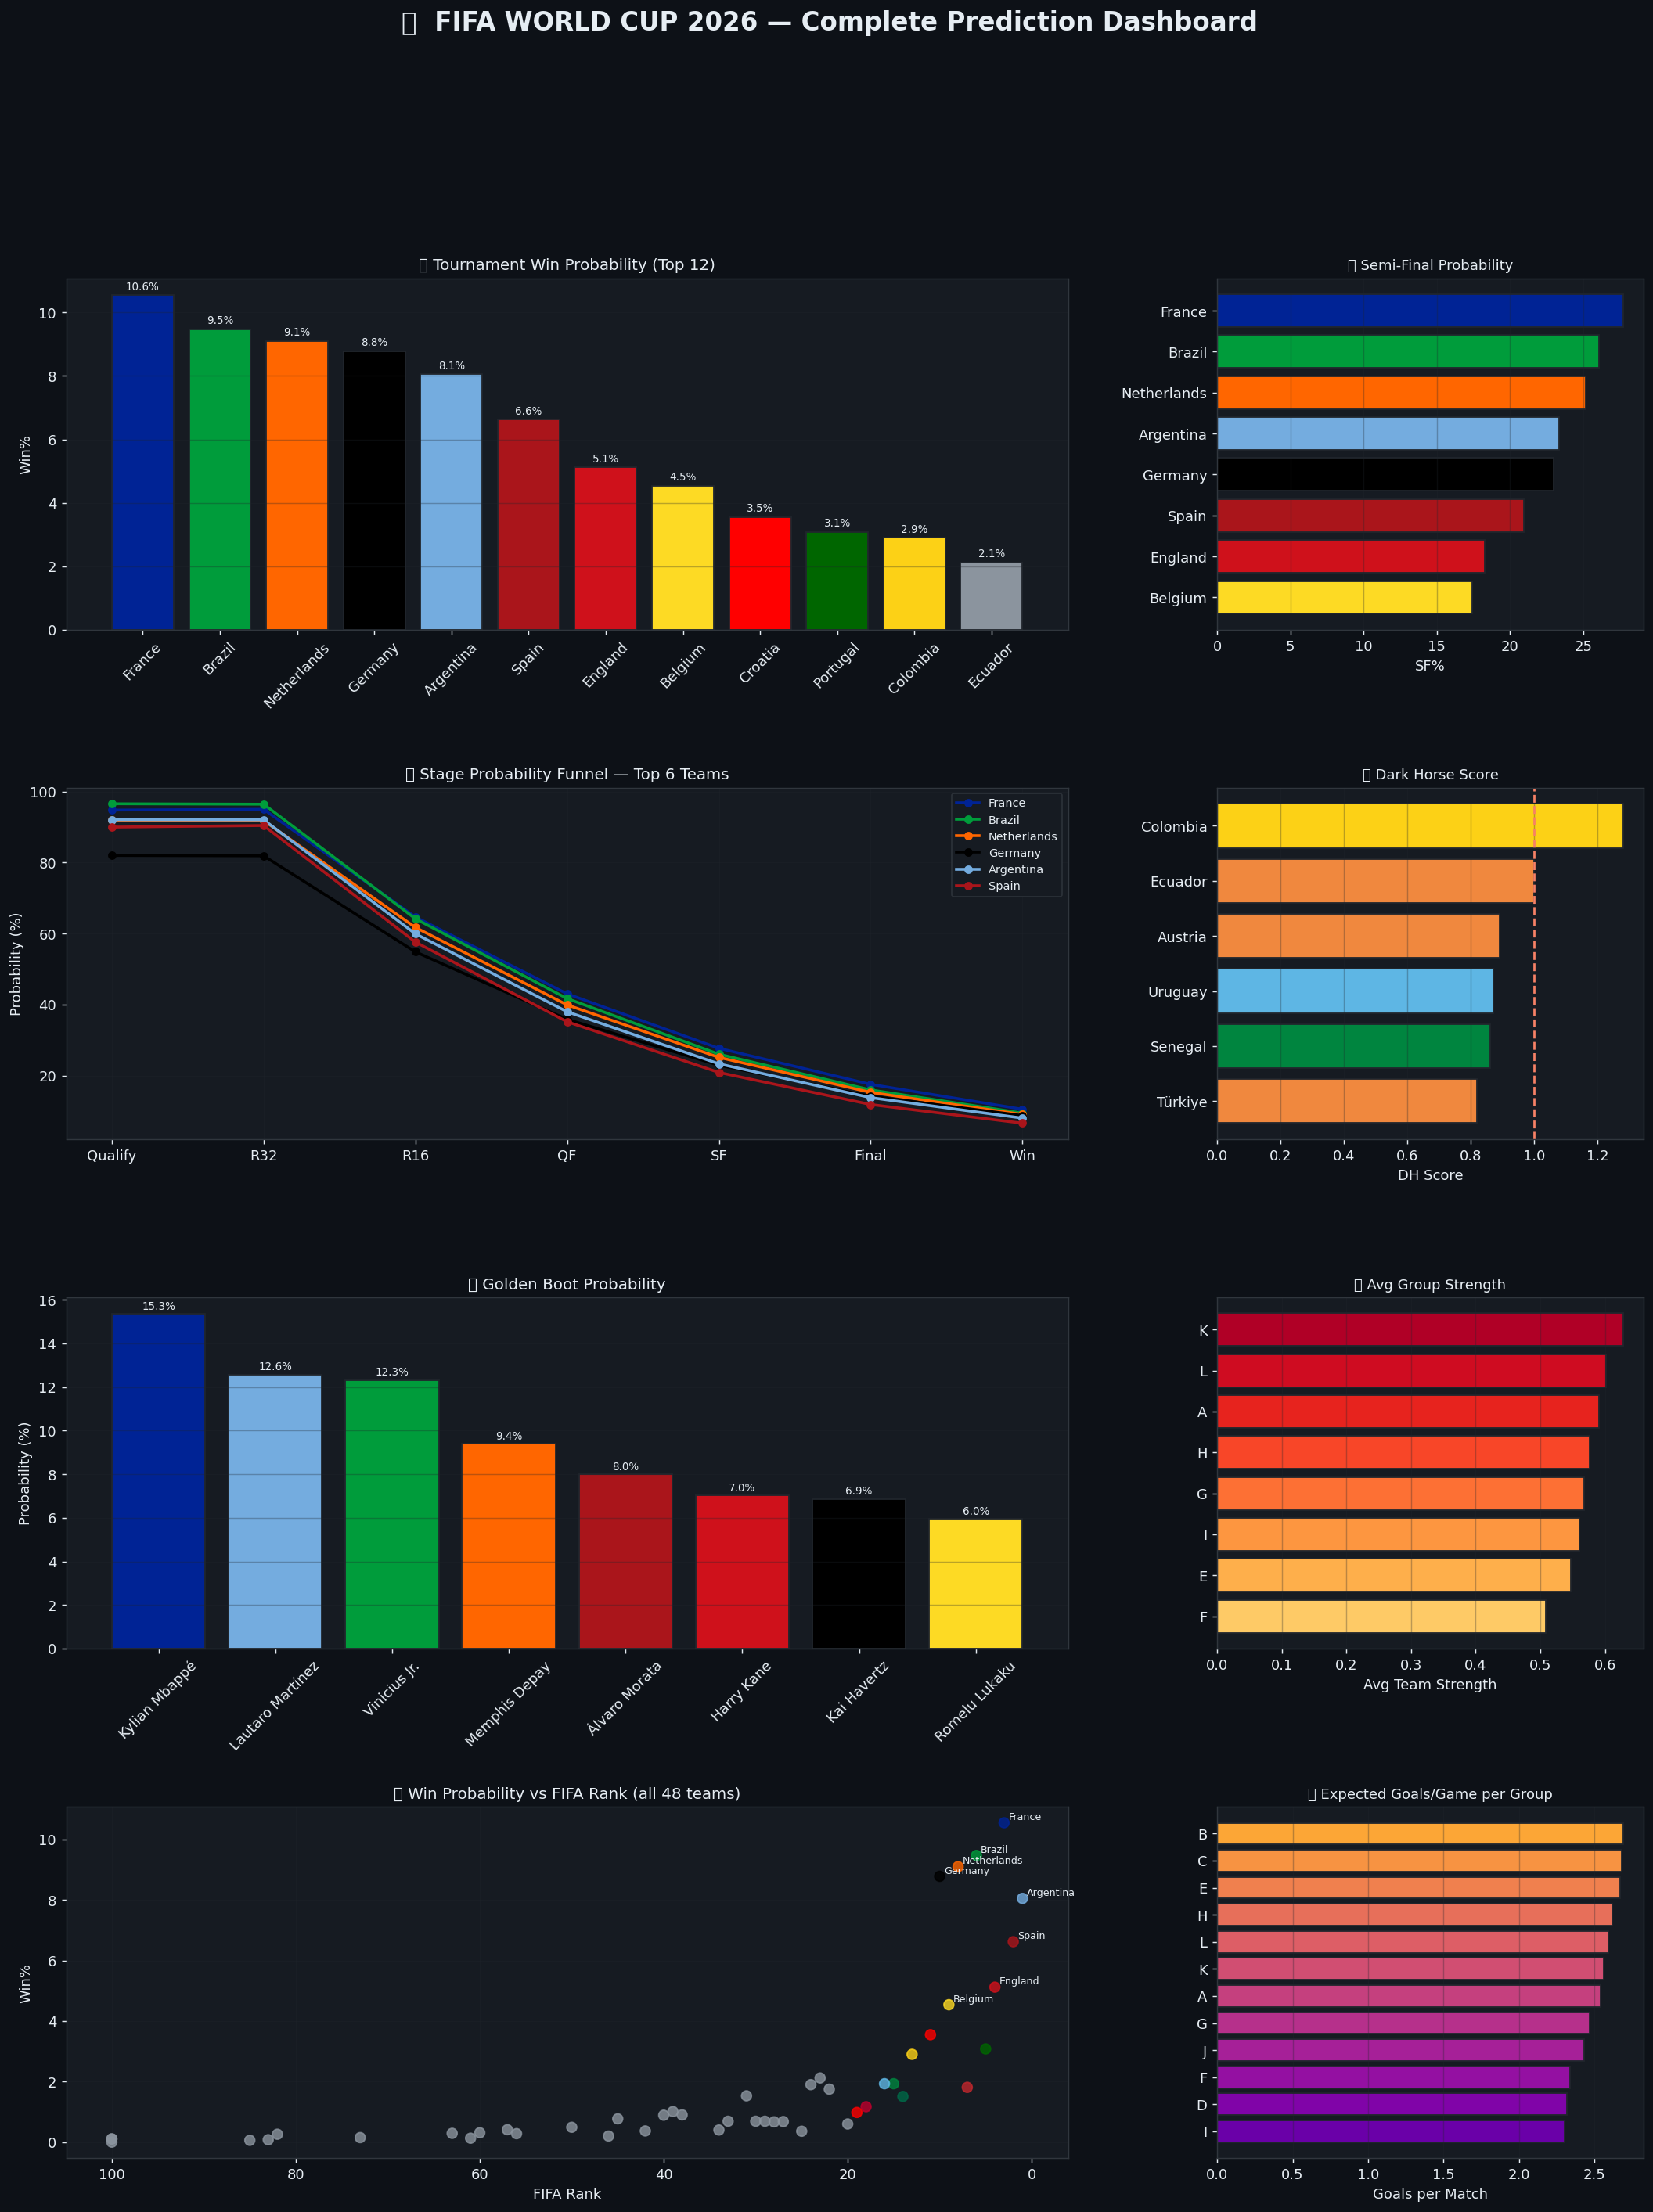

✅ Dashboard saved to WC2026_Dashboard.png


In [38]:
# ── Cell 11.1 ── Master dashboard (8-panel)
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor("#0d1117")
plt.suptitle("⚽  FIFA WORLD CUP 2026 — Complete Prediction Dashboard",
             fontsize=18, color="#e6edf3", y=0.99, fontweight="bold")

gs = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35)

# ── Panel 1: Win probabilities (top 12) ──────────────────────
ax1 = fig.add_subplot(gs[0, :2])
top12 = prob_df.head(12)
colors12 = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in top12["Team"]]
ax1.bar(top12["Team"], top12["Win%"], color=colors12, edgecolor="#21262d")
for i, (_, row) in enumerate(top12.iterrows()):
    ax1.text(i, row["Win%"] + 0.1, f"{row['Win%']:.1f}%",
             ha="center", va="bottom", fontsize=7.5, color="#e6edf3")
ax1.set_title("🏆 Tournament Win Probability (Top 12)", fontsize=11, color="#e6edf3")
ax1.set_ylabel("Win%"); ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: SF appearance rates ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sf_df = prob_df.nlargest(8, "SF%")
ax2.barh(sf_df["Team"][::-1], sf_df["SF%"][::-1],
         color=[TEAM_COLORS.get(t, DEFAULT_COLOR) for t in sf_df["Team"][::-1]],
         edgecolor="#21262d")
ax2.set_title("🥈 Semi-Final Probability", fontsize=10, color="#e6edf3")
ax2.set_xlabel("SF%"); ax2.grid(axis="x", alpha=0.3)

# ── Panel 3: Stage funnel for top 6 ──────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
stages_plot  = ["qualify","r32","r16","qf","sf","final","winner"]
stage_labels_plot = ["Qualify","R32","R16","QF","SF","Final","Win"]
for i, team in enumerate(prob_df.head(6)["Team"]):
    vals = [win_probs[team][s] for s in stages_plot]
    color = TEAM_COLORS.get(team, plt.cm.tab10(i/6))
    ax3.plot(stage_labels_plot, vals, marker="o", linewidth=2,
             markersize=5, label=team, color=color)
ax3.set_title("📈 Stage Probability Funnel — Top 6 Teams", fontsize=11, color="#e6edf3")
ax3.set_ylabel("Probability (%)"); ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── Panel 4: Dark horse DH score ────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
dh_top6 = dark_horse_df[dark_horse_df["FIFA_Rank"] > 12].head(6)
ax4.barh(dh_top6["Team"][::-1], dh_top6["DH_Score"][::-1],
         color=[TEAM_COLORS.get(t, "#f0883e") for t in dh_top6["Team"][::-1]],
         edgecolor="#21262d")
ax4.axvline(1.0, color="#f78166", linestyle="--", linewidth=1.5)
ax4.set_title("🌟 Dark Horse Score", fontsize=10, color="#e6edf3")
ax4.set_xlabel("DH Score"); ax4.grid(axis="x", alpha=0.3)

# ── Panel 5: Top scorer ──────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
sc_top8 = scorer_probs.head(8)
colors_sc5 = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in sc_top8["Team"]]
ax5.bar(sc_top8["Player"], sc_top8["TopScorer%"], color=colors_sc5, edgecolor="#21262d")
for i, (_, row) in enumerate(sc_top8.iterrows()):
    ax5.text(i, row["TopScorer%"] + 0.1, f"{row['TopScorer%']:.1f}%",
             ha="center", va="bottom", fontsize=7.5, color="#e6edf3")
ax5.set_title("🥇 Golden Boot Probability", fontsize=11, color="#e6edf3")
ax5.tick_params(axis="x", rotation=45); ax5.set_ylabel("Probability (%)")
ax5.grid(axis="y", alpha=0.3)

# ── Panel 6: Groups of death ──────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
gdf_plot = gdf.head(8)
ax6.barh(gdf_plot["Group"][::-1], gdf_plot["avg_strength"][::-1],
         color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(gdf_plot))),
         edgecolor="#21262d")
ax6.set_title("💀 Avg Group Strength", fontsize=10, color="#e6edf3")
ax6.set_xlabel("Avg Team Strength"); ax6.grid(axis="x", alpha=0.3)

# ── Panel 7: Win% vs FIFA rank scatter ───────────────────────
ax7 = fig.add_subplot(gs[3, :2])
all_ranks  = [team_strength[t]["fifa_rank"] for t in ALL_2026_TEAMS]
all_wins   = [win_probs[t]["winner"]        for t in ALL_2026_TEAMS]
scatter_colors = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in ALL_2026_TEAMS]
ax7.scatter(all_ranks, all_wins, c=scatter_colors, s=50, alpha=0.8, zorder=3)
for t in prob_df.head(8)["Team"]:
    ax7.annotate(t, (team_strength[t]["fifa_rank"], win_probs[t]["winner"]),
                 fontsize=7, color="#e6edf3", xytext=(3,2), textcoords="offset points")
ax7.set_title("📊 Win Probability vs FIFA Rank (all 48 teams)", fontsize=11, color="#e6edf3")
ax7.set_xlabel("FIFA Rank"); ax7.set_ylabel("Win%")
ax7.invert_xaxis(); ax7.grid(alpha=0.3)

# ── Panel 8: Predicted goals per group ───────────────────────
ax8 = fig.add_subplot(gs[3, 2])
gg_sorted = gg_df.sort_values("exp_goals_pg", ascending=True)
ax8.barh(gg_sorted["Group"], gg_sorted["exp_goals_pg"],
         color=plt.cm.plasma(np.linspace(0.2, 0.8, len(gg_sorted))),
         edgecolor="#21262d")
ax8.set_title("⚽ Expected Goals/Game per Group", fontsize=10, color="#e6edf3")
ax8.set_xlabel("Goals per Match"); ax8.grid(axis="x", alpha=0.3)

plt.savefig("WC2026_Dashboard.png", bbox_inches="tight", dpi=150,
            facecolor="#0d1117")
plt.show()
print("✅ Dashboard saved to WC2026_Dashboard.png")


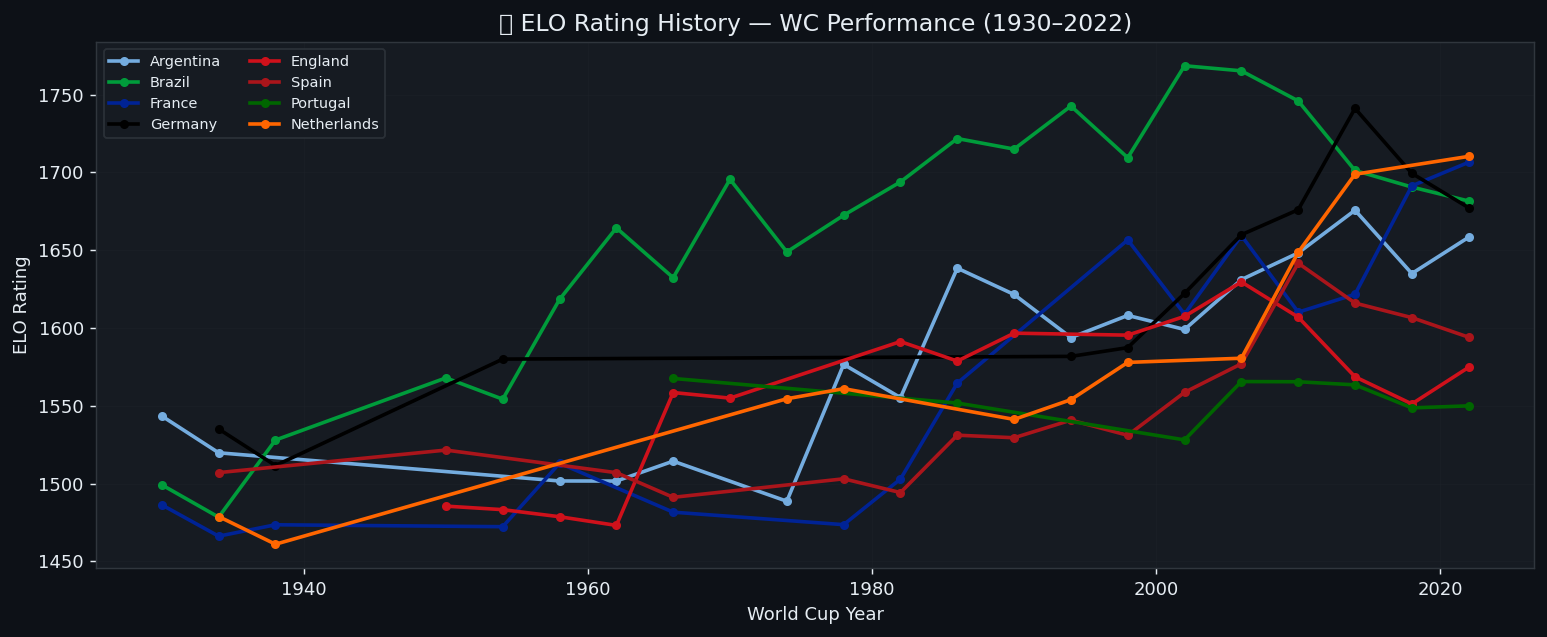

In [39]:
# ── Cell 11.2 ── ELO rating history for top nations
top_elo_teams = ["Argentina","Brazil","France","Germany","England","Spain","Portugal","Netherlands"]
elo_history_clean = {}
for team in top_elo_teams:
    if elo_history[team]:
        years, vals = zip(*elo_history[team])
        elo_history_clean[team] = (list(years), list(vals))

fig, ax = plt.subplots(figsize=(12, 5))
for team in top_elo_teams:
    if team in elo_history_clean:
        yrs, vals = elo_history_clean[team]
        color = TEAM_COLORS.get(team, DEFAULT_COLOR)
        ax.plot(yrs, vals, marker="o", linewidth=2, markersize=4, label=team, color=color)

ax.set_title("🏆 ELO Rating History — WC Performance (1930–2022)", fontsize=13)
ax.set_xlabel("World Cup Year"); ax.set_ylabel("ELO Rating")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
# ── Cell 11.3 ── Final summary printout
print("=" * 70)
print("        ⚽ FIFA WORLD CUP 2026 — FINAL PREDICTIONS SUMMARY")
print("=" * 70)

winner = prob_df.iloc[0]
finalist2 = prob_df.iloc[1]

print(f"\n🥇 MOST LIKELY WINNER  :  {winner['Team']:20s}  ({winner['Win%']:.1f}%)")
print(f"🥈 RUNNER-UP FAVOURITE  :  {finalist2['Team']:20s}  ({finalist2['Win%']:.1f}%)")
print()
print("📋 TOP 5 WIN PROBABILITIES:")
for _, row in prob_df.head(5).iterrows():
    bar = "█" * int(row["Win%"] * 2)
    print(f"   {row['Team']:20s}  {bar:<40s} {row['Win%']:.1f}%")

print()
print(f"🌟 DARK HORSE PICK      :  {dark_horse_df[dark_horse_df['FIFA_Rank']>12].iloc[0]['Team']}")
print(f"🥾 GOLDEN BOOT FAVOURITE:  {scorer_probs.iloc[0]['Player']} ({scorer_probs.iloc[0]['Team']})")
print()
print("💀 HARDEST GROUP:")
hardest = gdf.iloc[0]
print(f"   Group {hardest['Group']}: {hardest['teams']}")
print()
print("⚽ HIGHEST SCORING GROUP (predicted):")
highest_g = gg_df.iloc[0]
print(f"   Group {highest_g['Group']}: {highest_g['teams']}")
print(f"   Expected {highest_g['exp_goals_total']:.1f} total goals ({highest_g['exp_goals_pg']:.2f} per match)")
print()
print("=" * 70)
print(f"  Simulation: {N_SIMULATIONS:,} Monte Carlo iterations | Model: {best_name}")
print("=" * 70)


        ⚽ FIFA WORLD CUP 2026 — FINAL PREDICTIONS SUMMARY

🥇 MOST LIKELY WINNER  :  France                (10.6%)
🥈 RUNNER-UP FAVOURITE  :  Brazil                (9.5%)

📋 TOP 5 WIN PROBABILITIES:
   France                █████████████████████                    10.6%
   Brazil                ██████████████████                       9.5%
   Netherlands           ██████████████████                       9.1%
   Germany               █████████████████                        8.8%
   Argentina             ████████████████                         8.1%

🌟 DARK HORSE PICK      :  Colombia
🥾 GOLDEN BOOT FAVOURITE:  Kylian Mbappé (France)

💀 HARDEST GROUP:
   Group K: France, Iraq, Norway, Senegal

⚽ HIGHEST SCORING GROUP (predicted):
   Group B: Australia, Paraguay, Türkiye, United States
   Expected 16.2 total goals (2.69 per match)

  Simulation: 50,000 Monte Carlo iterations | Model: XGBoost
